In [17]:
#importing necessary libraries and loading the dataset

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv("/Users/hughesy/Documents/FinalProject/data/processed/analytical_dataset.csv")

## Create a function for consistant chart styles


In [18]:
def style_chart(
    title,
    xlabel,
    ylabel,
    legend_title=None,
    legend_outside=True,
    grid_axis="y",
    rotation=0,
    chart_bg="#f8ead6"
):

    # Title
    plt.title(
        title,
        fontsize=16,
        fontweight="bold",
        pad=15
    )

    # Axis labels
    plt.xlabel(
        xlabel,
        fontsize=12
    )

    plt.ylabel(
        ylabel,
        fontsize=12
    )

    # X tick formatting
    plt.xticks(
        rotation=rotation,
        ha="right" if rotation else "center"
    )

    # Legend
    if legend_title:

        if legend_outside:
            plt.legend(
                title=legend_title,
                frameon=False,
                bbox_to_anchor=(1.02, 1),
                loc="upper left"
            )

        else:
            plt.legend(
                title=legend_title,
                frameon=False
            )

    # Background colours
    plt.gcf().set_facecolor(chart_bg)
    plt.gca().set_facecolor(chart_bg)

    # Styling
    sns.despine()

    plt.grid(
        axis=grid_axis,
        alpha=0.3,
        color="#d8c7ae"
    )

    plt.tight_layout()

## Demographics

In [19]:
df["age"].describe()

count    8153.000000
mean       52.144364
std        18.553060
min        18.000000
25%        36.000000
50%        55.000000
75%        68.000000
max        80.000000
Name: age, dtype: float64

In [22]:
# Create category mapping dictionaries for better readability in plots
#  Demographics

gender_labels = {
    1: "Male",
    2: "Female"
}

ethnicity_labels = {
    1: "Mexican American",
    2: "Other Hispanic",
    3: "Non-Hispanic White",
    4: "Non-Hispanic Black",
    6: "Non-Hispanic Asian",
    7: "Other / Multi-Racial"
}

# Alcohol

alc_consum_labels = {
    1: "Yes",
    2: "No"
}

alcohol_map = {
    0: "Former / None Last Year",

    1: "Daily / Near Daily",
    2: "Daily / Near Daily",

    3: "Weekly",
    4: "Weekly",
    5: "Weekly",

    6: "Monthly",
    7: "Monthly",

    8: "Few Times / Year",
    9: "Few Times / Year",
    10: "Few Times / Year"
}


# Smoking

smoked_100_cigs_labels = {
    1: "Yes",
    2: "No"
}

smoker_now_labels = {
    1: "Every Day",
    2: "Some Days",
    3: "Not At All"
}


# Blood Pressure

high_bp_labels = {
    1: "Yes",
    2: "No"
}

bp_medication_labels = {
    1: "Yes",
    2: "No"
}


# Cholesterol

high_cholesterol_labels = {
    1: "Yes",
    2: "No"
}

cholesterol_medication_labels = {
    1: "Yes",
    2: "No"
}


# Diabetes

diabetes_labels = {
    1: "Yes",
    2: "No",
    3: "Borderline"
}

pre_diabetes_labels = {
    1: "Yes",
    2: "No"
}

insulin_labels = {
    1: "Yes",
    2: "No"
}

diabetes_medication_labels = {
    1: "Yes",
    2: "No"
}

In [23]:
# distribution of age and gender
pd.crosstab(df["age"], df["gender"].map(gender_labels), normalize="index") * 100

gender,Female,Male
age,,
18.0,44.021739,55.978261
19.0,58.750000,41.250000
20.0,43.661972,56.338028
21.0,48.809524,51.190476
22.0,54.117647,45.882353
...,...,...
76.0,49.038462,50.961538
77.0,58.333333,41.666667
78.0,61.643836,38.356164


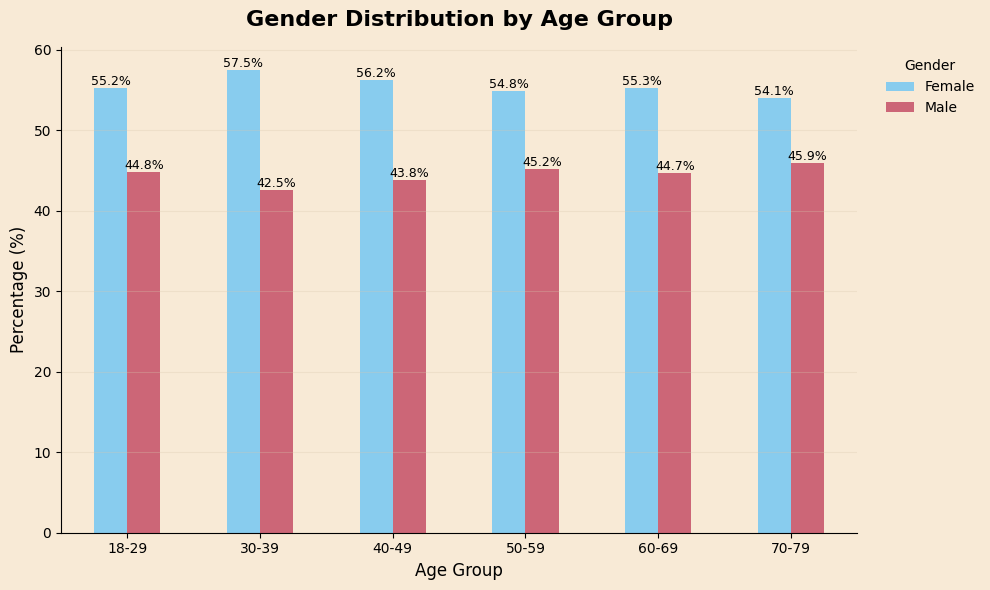

In [24]:
import seaborn as sns

# Create age groups
df["age_group"] = pd.cut(
    df["age"],
    bins=[18,30,40,50,60,70,80,100],
    labels=[
        "18-29",
        "30-39",
        "40-49",
        "50-59",
        "60-69",
        "70-79",
        "80+"
    ]
)

# Calculate percentage of each gender within each age group
age_gender_pct = (
    pd.crosstab(
        df["age_group"],
        df["gender"].map(gender_labels),
        normalize="index"
    ) * 100
)
 # Plotting
ax = age_gender_pct.plot(
    kind="bar",
    figsize=(10,6),
    color=["#88CCEE", "#CC6677"]
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        fontsize=9
    )

style_chart(
    title="Gender Distribution by Age Group",
    xlabel="Age Group",
    ylabel="Percentage (%)",
    legend_title="Gender"
)

plt.show()

## Ethnicity & Gender

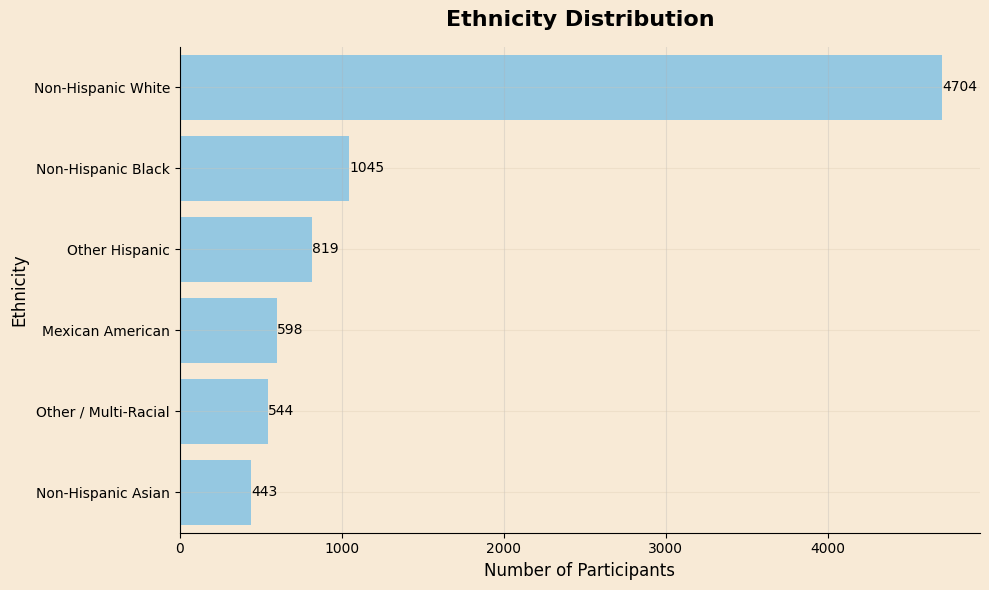

In [25]:
ethnicity_mapped = df["ethnicity"].map(ethnicity_labels)

plt.figure(figsize=(10, 6))

ax = sns.countplot(
    y=ethnicity_mapped,
    order=ethnicity_mapped.value_counts().index,
    color="#88CCEE"
)

for container in ax.containers:
    ax.bar_label(container)

style_chart(
    title="Ethnicity Distribution",
    xlabel="Number of Participants",
    ylabel="Ethnicity"
)

plt.grid(axis="x", alpha=0.3)

plt.show()

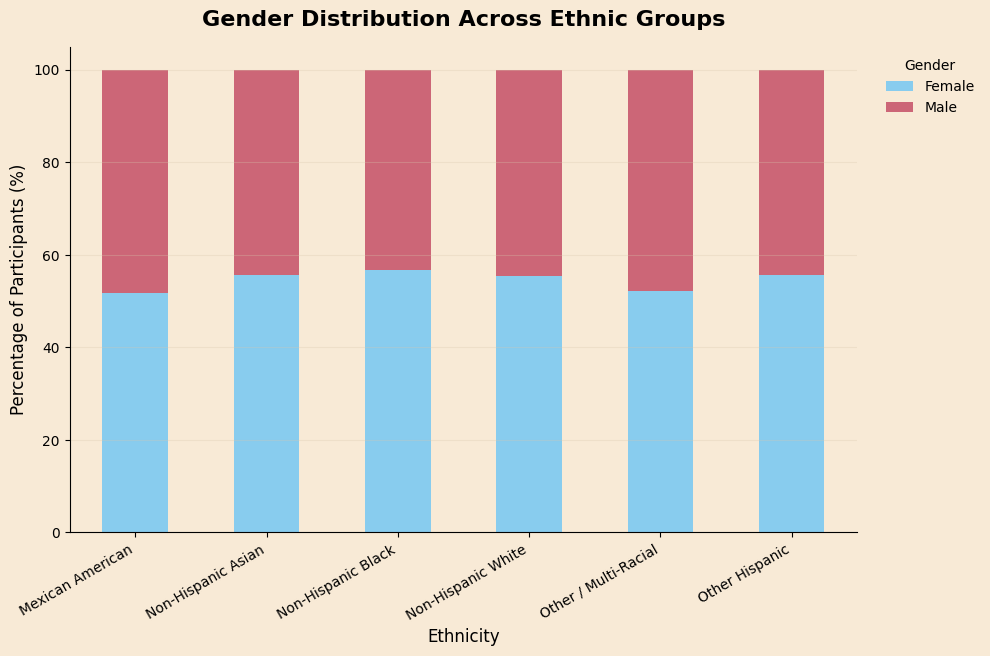

In [26]:
eth_gender = (
    pd.crosstab(
        df["ethnicity"].map(ethnicity_labels),
        df["gender"].map(gender_labels),
        normalize="index"
    ) * 100
)

ax = eth_gender.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    color=["#88CCEE", "#CC6677"]
)

style_chart(
    title="Gender Distribution Across Ethnic Groups",
    xlabel="Ethnicity",
    ylabel="Percentage of Participants (%)",
    legend_title="Gender",
    grid_axis="y"
)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.show()

## Body Mass Index


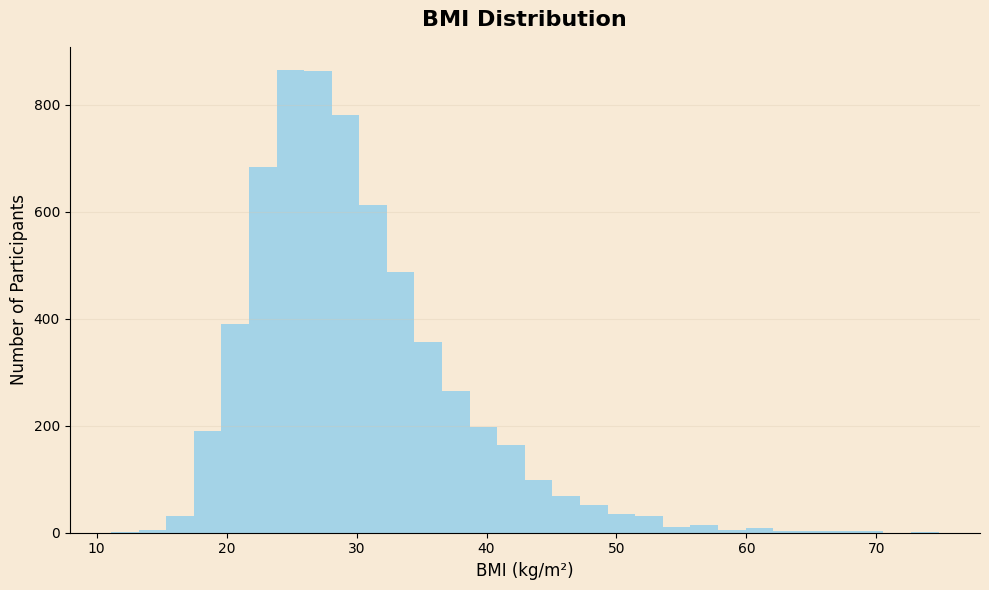

In [27]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="bmi",
    bins=30,
    color="#88CCEE",
    linewidth=0
)

style_chart(
    title="BMI Distribution",
    xlabel="BMI (kg/m²)",
    ylabel="Number of Participants",
    grid_axis="y"
)

plt.show()

In [28]:
df["bmi"].describe()

count    6235.000000
mean       29.659326
std         7.395826
min        11.100000
25%        24.500000
50%        28.300000
75%        33.400000
max        74.800000
Name: bmi, dtype: float64

In [29]:
df["bmi"].sort_values(ascending=False).head(10)

3533    74.8
1105    69.9
3276    69.1
2721    68.9
2678    68.5
6698    67.8
3060    67.1
432     66.5
4903    65.2
3366    64.7
Name: bmi, dtype: float64

In [30]:
df["bmi_category"] = pd.cut(
    df["bmi"],
    bins=[0, 18.5, 25, 30, 100],
    labels=[
        "Underweight",
        "Normal",
        "Overweight",
        "Obese"
    ]
)

(
    df["bmi_category"]
    .value_counts(normalize=True)
    .mul(100)
)

bmi_category
Obese          40.000000
Overweight     31.259022
Normal         26.880513
Underweight     1.860465
Name: proportion, dtype: float64

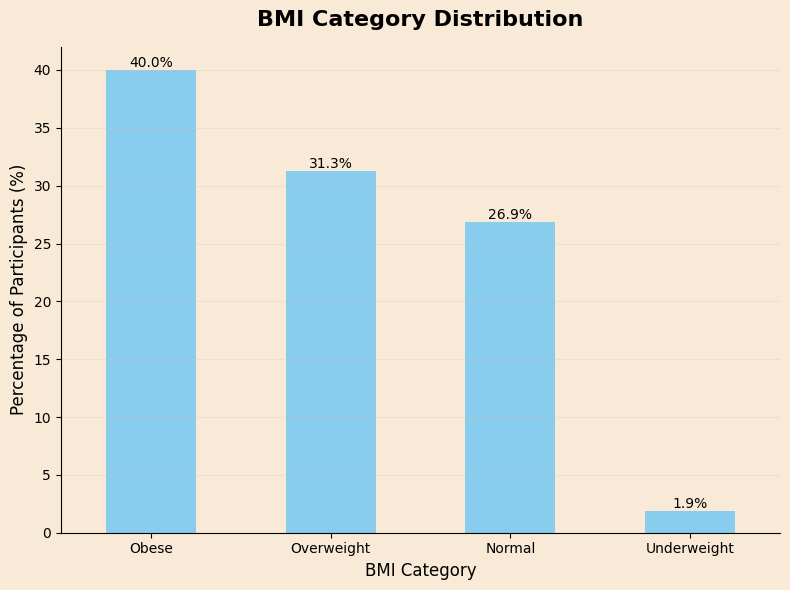

In [31]:
bmi_pct = (
    df["bmi_category"]
    .value_counts(normalize=True)
    .mul(100)
    .sort_values(ascending=False)
)

ax = bmi_pct.plot(
    kind="bar",
    figsize=(8, 6),
    color="#88CCEE"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

style_chart(
    title="BMI Category Distribution",
    xlabel="BMI Category",
    ylabel="Percentage of Participants (%)",
    grid_axis="y",
    rotation=0
)

plt.show()

## Smoking

In [34]:
[col for col in df.columns if "smok" in col.lower()]

['smoked_100_cigs?', 'smoker_now?']

In [35]:
df["smoking_status"] = pd.Series(pd.NA, index=df.index, dtype="object")

df.loc[df["smoked_100_cigs?"] == 2, "smoking_status"] = "Never"

df.loc[df["smoker_now?"] == 3, "smoking_status"] = "Former"

df.loc[df["smoker_now?"] == 2, "smoking_status"] = "Current Some Days"

df.loc[df["smoker_now?"] == 1, "smoking_status"] = "Current Every Day"

df["smoking_status"].value_counts(dropna=False)

smoking_status
Never                3810
<NA>                 1825
Former               1597
Current Every Day     741
Current Some Days     180
Name: count, dtype: int64

In [36]:
smoking_df = df[df["smoking_status"].notna()].copy()

In [37]:
smoking_score_map = {
    "Never": 0,
    "Former": 1,
    "Current Some Days": 2,
    "Current Every Day": 3
}

df["smoking_score"] = df["smoking_status"].map(smoking_score_map)
smoking_df["smoking_score"] = smoking_df["smoking_status"].map(smoking_score_map)

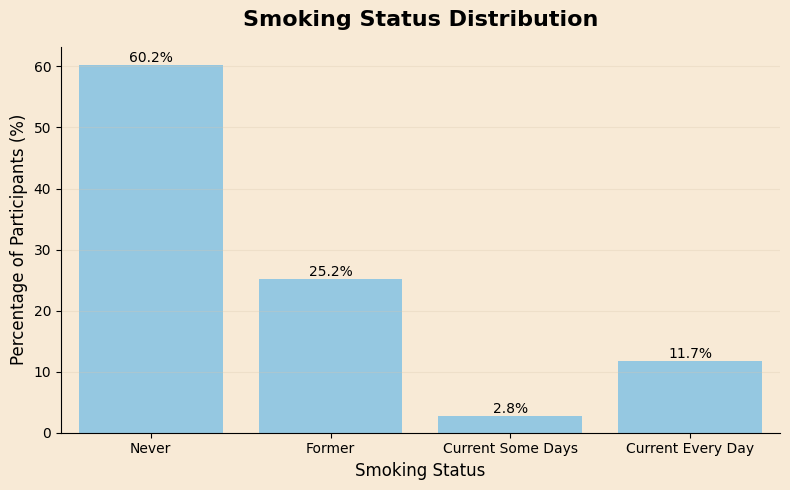

In [39]:
# Smoking status distribution (%)

smoking_distribution = (
    smoking_df["smoking_status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
    .reindex([
        "Never",
        "Former",
        "Current Some Days",
        "Current Every Day"
    ])
)

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=smoking_distribution.index,
    y=smoking_distribution.values,
    color="#88CCEE"
)

style_chart(
    title="Smoking Status Distribution",
    xlabel="Smoking Status",
    ylabel="Percentage of Participants (%)"
)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        fontsize=10
    )

plt.show()
plt.show()

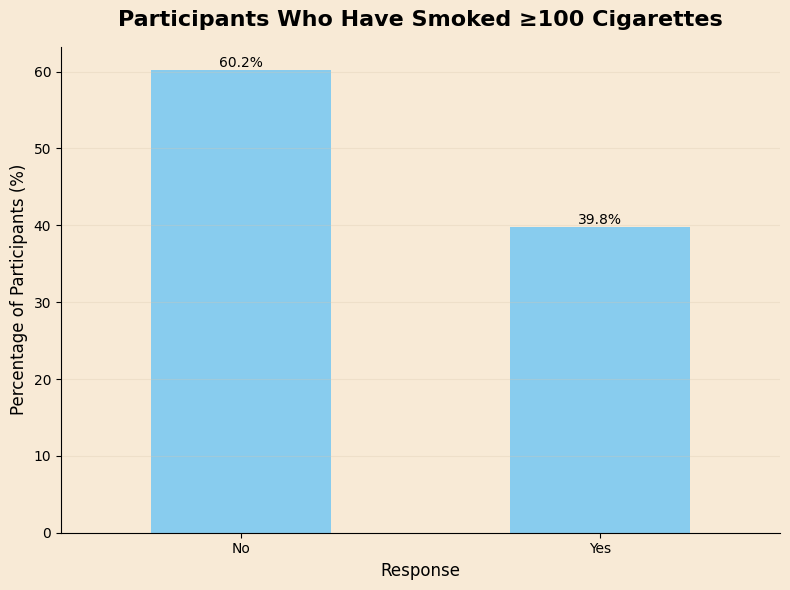

In [40]:
ever_smoked_pct = (
    df["smoked_100_cigs?"]
    .map(smoked_100_cigs_labels)
    .value_counts(normalize=True)
    .mul(100)
)

ax = ever_smoked_pct.plot(
    kind="bar",
    figsize=(8, 6),
    color="#88CCEE"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

style_chart(
    title="Participants Who Have Smoked ≥100 Cigarettes",
    xlabel="Response",
    ylabel="Percentage of Participants (%)"
)

plt.show()

## Diabetes

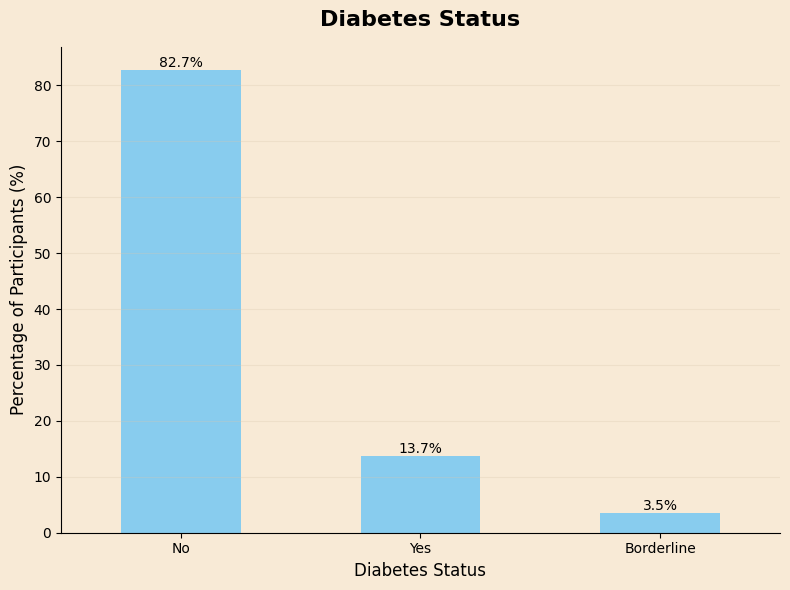

In [41]:
diabetes_pct = (
    df["diabetes?"]
    .map(diabetes_labels)
    .value_counts(normalize=True)
    .mul(100)
)

ax = diabetes_pct.plot(
    kind="bar",
    figsize=(8, 6),
    color="#88CCEE"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

style_chart(
    title="Diabetes Status",
    xlabel="Diabetes Status",
    ylabel="Percentage of Participants (%)"
)

plt.show()

## Blood Pressure

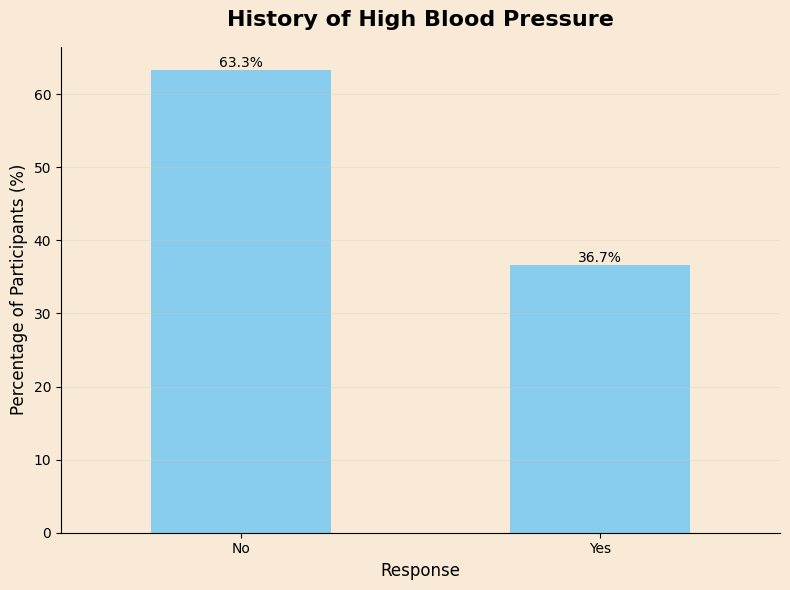

In [42]:
bp_pct = (
    df["high_bp?"]
    .map(high_bp_labels)
    .value_counts(normalize=True)
    .mul(100)
)

ax = bp_pct.plot(
    kind="bar",
    figsize=(8, 6),
    color="#88CCEE"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

style_chart(
    title="History of High Blood Pressure",
    xlabel="Response",
    ylabel="Percentage of Participants (%)"
)

plt.show()

## Alcohol

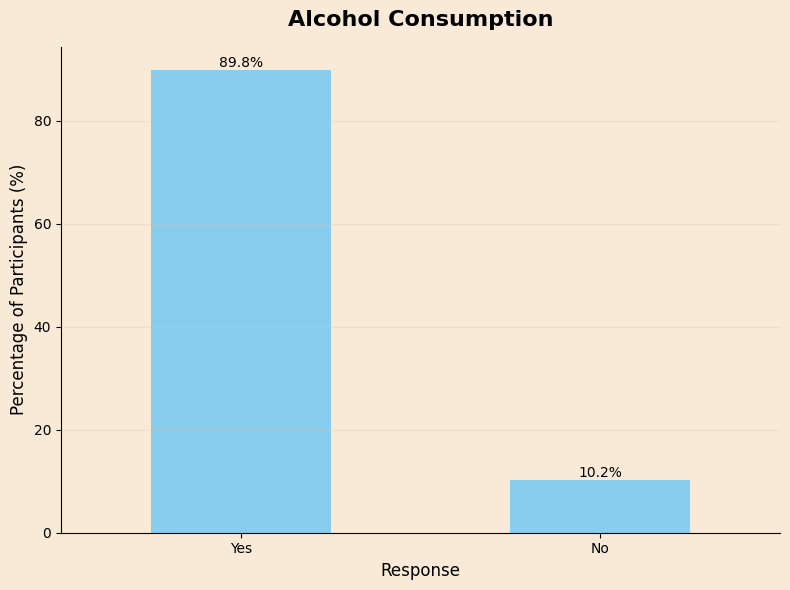

In [43]:
alc_pct = (
    df["alc_consum?"]
    .map(alc_consum_labels)
    .value_counts(normalize=True)
    .mul(100)
)

ax = alc_pct.plot(
    kind="bar",
    figsize=(8, 6),
    color="#88CCEE"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

style_chart(
    title="Alcohol Consumption",
    xlabel="Response",
    ylabel="Percentage of Participants (%)"
)

plt.show()

In [44]:
alcohol_freq_map = {
    0: "Never",
    1: "Daily / Near daily",
    2: "Daily / Near daily",
    3: "Weekly",
    4: "Weekly",
    5: "Weekly",
    6: "Monthly",
    7: "Monthly",
    8: "Few times/year",
    9: "Few times/year",
    10: "Few times/year"
}

df["alcohol_frequency_group"] = df["avg_drink_day_12m"].map(alcohol_freq_map)

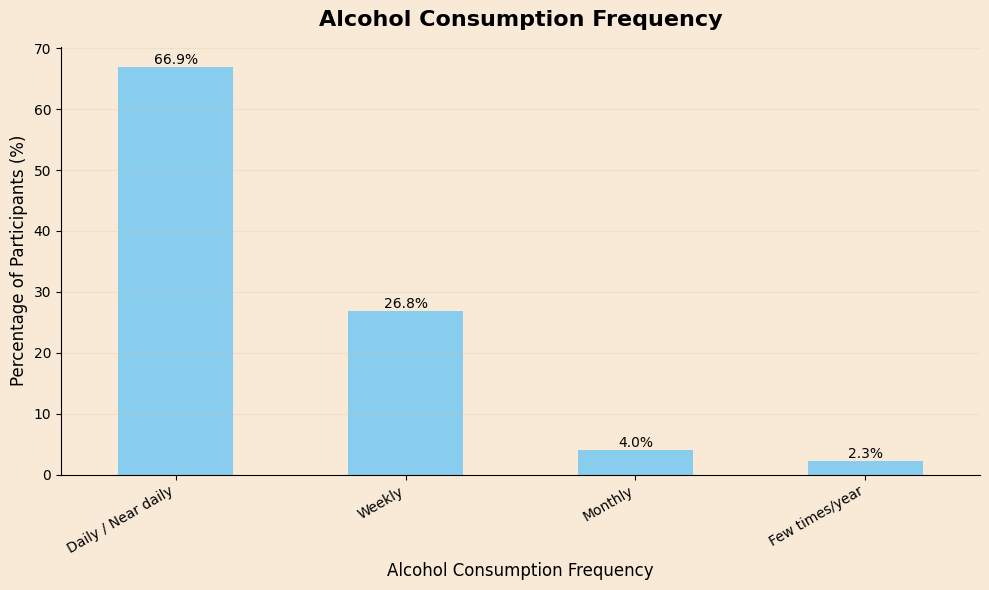

In [45]:
alcohol_order = [
    "Never",
    "Few times/year",
    "Monthly",
    "Weekly",
    "Daily / Near daily"
]

alcohol_pct = (
    df["alcohol_frequency_group"]
    .value_counts(normalize=True)
    .mul(100)
    .sort_values(ascending=False)
)

ax = alcohol_pct.plot(
    kind="bar",
    figsize=(10, 6),
    color="#88CCEE"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

style_chart(
    title="Alcohol Consumption Frequency",
    xlabel="Alcohol Consumption Frequency",
    ylabel="Percentage of Participants (%)",
    rotation=30
)

plt.show()

In [46]:
df = df.rename(columns={
    "avg_drink_day_12m": "alcohol_frequency_12m"
})

## BMI and CRP Comparisons

In [47]:
# Explore relationship between BMI category and CRP levels (median CRP by BMI category)

df.groupby(
    "bmi_category",
    observed=True
)["crp_mg/l"].median()

bmi_category
Underweight    0.610
Normal         0.850
Overweight     1.505
Obese          3.450
Name: crp_mg/l, dtype: float64

In [48]:
# Explore relationship between BMI category and CRP levels (mean CRP by BMI category)
df.groupby(
    "bmi_category",
    observed=True
)["crp_mg/l"].mean()

bmi_category
Underweight    2.883297
Normal         2.049195
Overweight     2.894730
Obese          5.775626
Name: crp_mg/l, dtype: float64

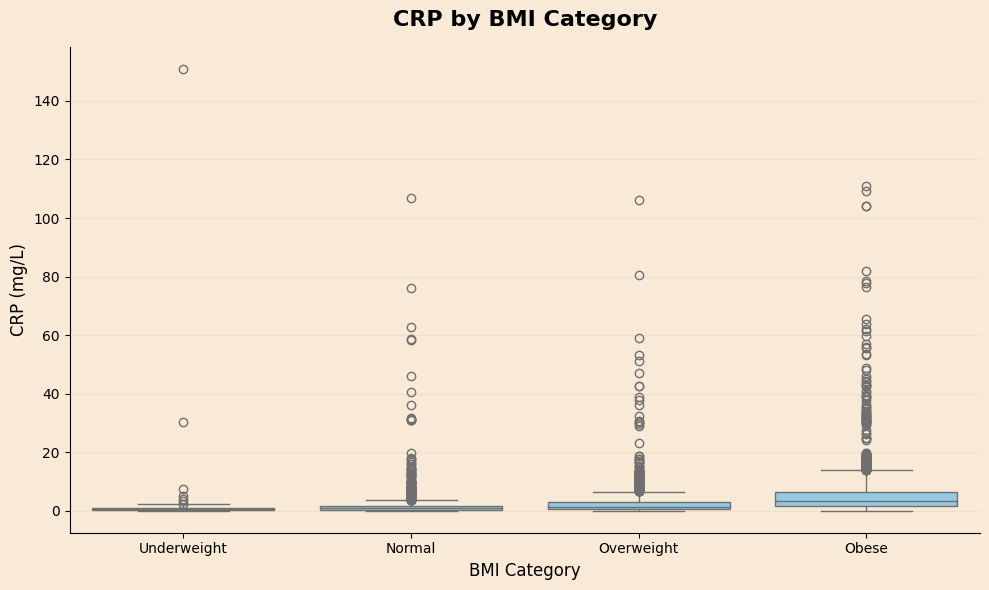

In [49]:
# Visualize relationship between BMI category and CRP levels using boxplot
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="bmi_category",
    y="crp_mg/l",
    color="#88CCEE"
)

style_chart(
    title="CRP by BMI Category",
    xlabel="BMI Category",
    ylabel="CRP (mg/L)"
)

plt.show()

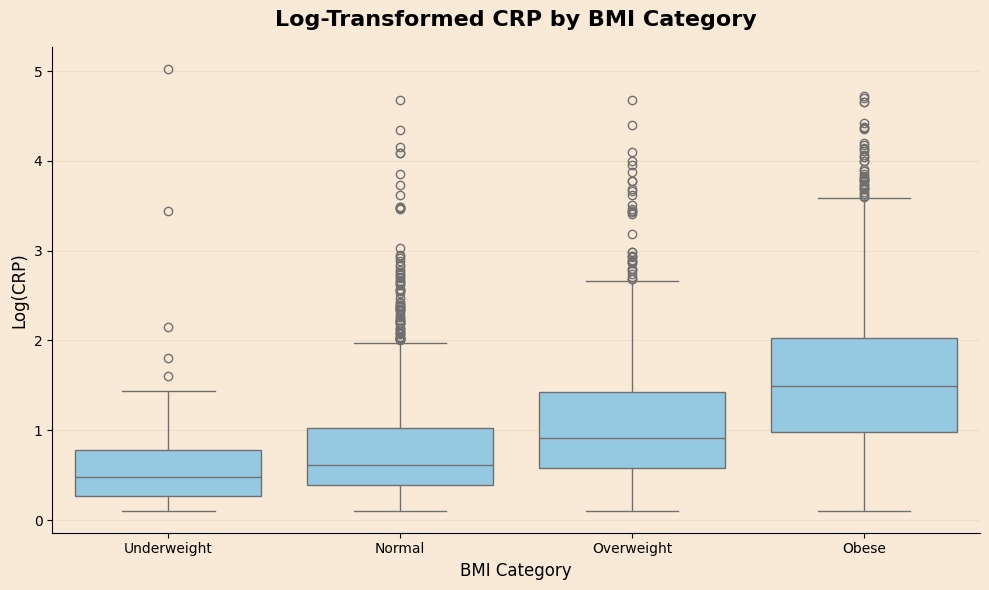

In [50]:
import numpy as np

# Since CRP is often right-skewed, we can log-transform it for better visualization
plt.figure(figsize=(10,6))

sns.boxplot(
    x=df["bmi_category"],
    y=np.log1p(df["crp_mg/l"]),
    color="#88CCEE"
)

style_chart(
    title="Log-Transformed CRP by BMI Category",
    xlabel="BMI Category",
    ylabel="Log(CRP)"
)

plt.show()

In [51]:
import numpy as np

df["log_crp"] = np.log1p(df["crp_mg/l"])

In [52]:
# Calculate median log-transformed CRP by BMI category, which can be more robust to outliers than the mean
df.groupby(
    "bmi_category",
    observed=True
)["log_crp"].median()

bmi_category
Underweight    0.476234
Normal         0.615186
Overweight     0.918287
Obese          1.492904
Name: log_crp, dtype: float64

In [53]:
# Calculate correlation between BMI and CRP levels

df[["bmi", "crp_mg/l"]].corr()

,bmi,crp_mg/l
bmi,1.000000,0.292554
crp_mg/l,0.292554,1.000000


## BMI and NLR (Neurophil to Lymphocyte Ratio)

In [54]:
# Explore relationship between BMI category and NLR (median NLR by BMI category)
df.groupby(
    "bmi_category",
    observed=True
)["nlr"].median()

bmi_category
Underweight    2.055556
Normal         1.937500
Overweight     1.947368
Obese          2.040000
Name: nlr, dtype: float64

In [55]:
# Explore relationship between BMI category and NLR (median NLR by BMI category)
df.groupby(
    "bmi_category",
    observed=True
)["nlr"].mean()

bmi_category
Underweight    2.174942
Normal         2.230376
Overweight     2.220544
Obese          2.274025
Name: nlr, dtype: float64

In [56]:
# Calculate correlation between BMI and NLR levels
df[["bmi", "nlr"]].corr()

,bmi,nlr
bmi,1.000000,0.045137
nlr,0.045137,1.000000


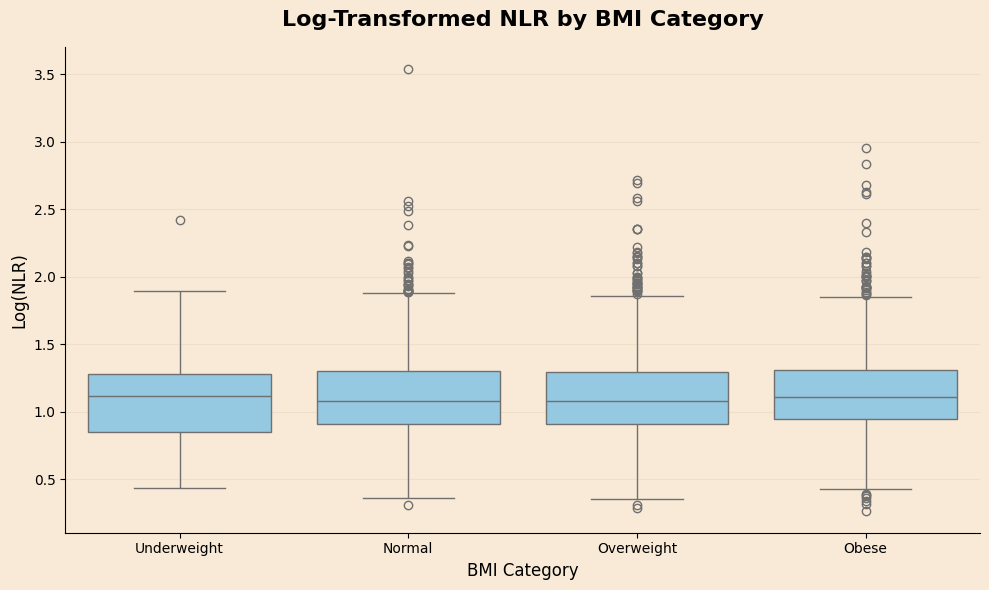

In [57]:
import numpy as np
# Since NLR is often right-skewed, we can log-transform it for better visualization
plt.figure(figsize=(10,6))

sns.boxplot(
    x=df["bmi_category"],
    y=np.log1p(df["nlr"]),
    color="#88CCEE"
)

style_chart(
    title="Log-Transformed NLR by BMI Category",
    xlabel="BMI Category",
    ylabel="Log(NLR)"
)

plt.show()

In [58]:
df["log_nlr"] = np.log1p(df["nlr"])

In [59]:
df.groupby(
    "bmi_category",
    observed=True
)["log_nlr"].median()

bmi_category
Underweight    1.116961
Normal         1.077559
Overweight     1.080913
Obese          1.111858
Name: log_nlr, dtype: float64

In [60]:
# Calculate correlation between waist-hip ratio and CRP levels
df[["waist_hip_ratio", "crp_mg/l"]].corr()

,waist_hip_ratio,crp_mg/l
waist_hip_ratio,1.000000,0.095477
crp_mg/l,0.095477,1.000000


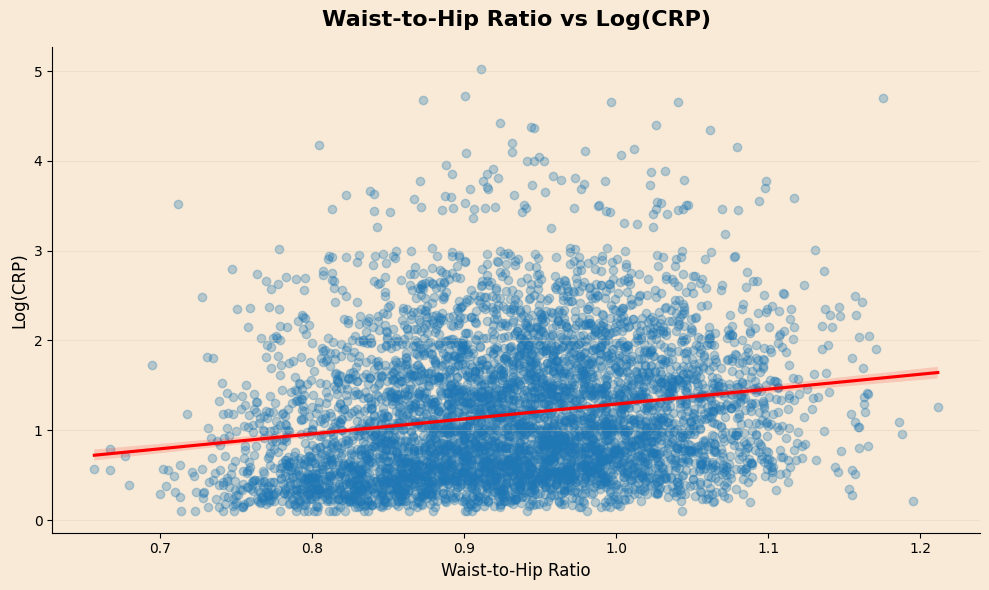

In [61]:
# Visualize relationship between waist-hip ratio and CRP levels using scatterplot

plt.figure(figsize=(10,6))

sns.regplot(
    data=df,
    x="waist_hip_ratio",
    y="log_crp",
    scatter_kws={"alpha":0.3},
    line_kws={"color":"red"}
)

style_chart(
    title="Waist-to-Hip Ratio vs Log(CRP)",
    xlabel="Waist-to-Hip Ratio",
    ylabel="Log(CRP)"
)

plt.show()

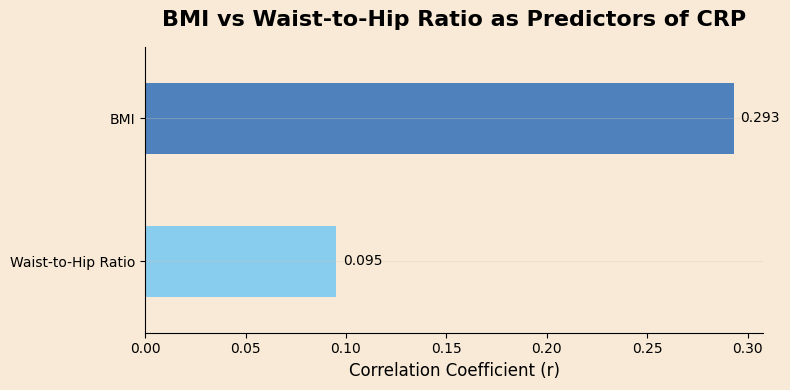

In [62]:
corr_df = pd.DataFrame({
    "Measure": ["BMI", "Waist-to-Hip Ratio"],
    "Correlation with CRP": [0.293, 0.095]
})

ax = corr_df.plot(
    x="Measure",
    y="Correlation with CRP",
    kind="barh",
    figsize=(8,4),
    color=["#4F81BD", "#88CCEE"],
    legend=False
)
ax.invert_yaxis()
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=5
    )

style_chart(
    title="BMI vs Waist-to-Hip Ratio as Predictors of CRP",
    xlabel="Correlation Coefficient (r)",
    ylabel=""
)

plt.show()

## Smoking effect on WBC count  

Apparent missing values in the current smoking variable were investigated and found to result from questionnaire skip logic. A new smoking status variable was created by combining lifetime smoking history and current smoking behaviour, allowing participants to be classified as never, former, occasional, or daily smokers.

In [63]:
print(df['smoker_now?'].value_counts(dropna=False))

smoker_now?
NaN    5635
3.0    1597
1.0     741
2.0     180
Name: count, dtype: int64


In [64]:
print(df["smoker_now?"].isna().mean() * 100)

print(df["smoked_100_cigs?"].value_counts(dropna=False))

69.11566294615479
smoked_100_cigs?
2.0    3810
1.0    2518
NaN    1818
9.0       4
7.0       3
Name: count, dtype: int64


In [65]:
#create smoking status variable based on smoking history and current smoking status questions

df["smoking_status"] = pd.NA
df["smoking_status"] = df["smoking_status"].astype("object")

df.loc[df["smoked_100_cigs?"] == 2, "smoking_status"] = "Never"
df.loc[df["smoker_now?"] == 3, "smoking_status"] = "Former"
df.loc[df["smoker_now?"] == 2, "smoking_status"] = "Current Some Days"
df.loc[df["smoker_now?"] == 1, "smoking_status"] = "Current Every Day"

df["smoking_status"].value_counts(dropna=False)

smoking_status
Never                3810
<NA>                 1825
Former               1597
Current Every Day     741
Current Some Days     180
Name: count, dtype: int64

In [66]:
smoking_df = df[df["smoking_status"].notna()]

In [67]:
# Calculate median WBC count by current smoking status
wbc_median = smoking_df.groupby(
    "smoking_status",
    observed=True
)["wbc_abs."].median()

wbc_median

smoking_status
Current Every Day    7.60
Current Some Days    7.15
Former               6.70
Never                6.40
Name: wbc_abs., dtype: float64

In [68]:
# Calculate mean WBC count by current smoking status
wbc_mean = smoking_df.groupby(
    "smoking_status",
    observed=True
)["wbc_abs."].mean()

wbc_mean

smoking_status
Current Every Day    7.874891
Current Some Days    7.416071
Former               6.963827
Never                6.684679
Name: wbc_abs., dtype: float64

In [69]:
# Calculate percentage difference in median WBC count compared to never smokers

wbc_median = (
    smoking_df.groupby(
        "smoking_status",
        observed=True
    )["wbc_abs."]
    .median()
    .reindex([
        "Never",
        "Former",
        "Current Some Days",
        "Current Every Day"
    ])
)

(
    (wbc_median - wbc_median["Never"])
    / wbc_median["Never"]
    * 100
).round(1)

smoking_status
Never                 0.0
Former                4.7
Current Some Days    11.7
Current Every Day    18.7
Name: wbc_abs., dtype: float64

In [70]:
# Calculate percentage difference in mean WBC count compared to never smokers

wbc_mean = (
    smoking_df.groupby(
        "smoking_status",
        observed=True
    )["wbc_abs."]
    .mean()
    .reindex([
        "Never",
        "Former",
        "Current Some Days",
        "Current Every Day"
    ])
)

(
    (wbc_mean - wbc_mean["Never"])
    / wbc_mean["Never"]
    * 100
).round(1)

smoking_status
Never                 0.0
Former                4.2
Current Some Days    10.9
Current Every Day    17.8
Name: wbc_abs., dtype: float64

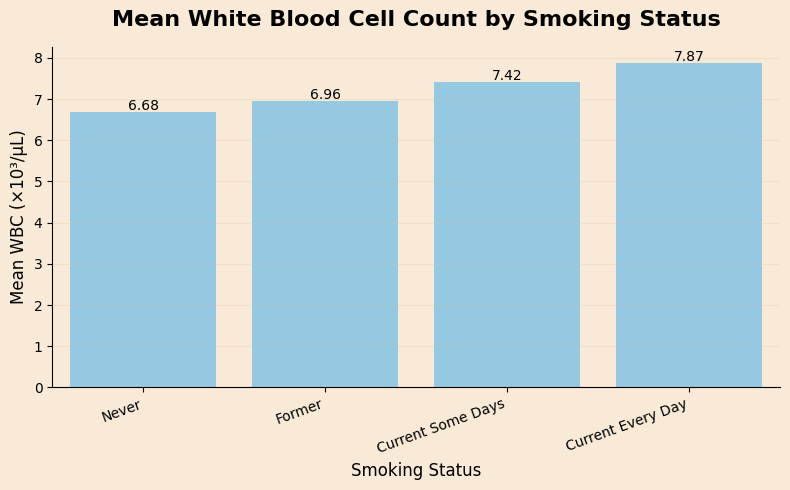

In [71]:
# Visualize mean WBC count by smoking status using bar plot

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=wbc_mean.index,
    y=wbc_mean.values,
    color="#88CCEE"
)

# Add values on top
for i, value in enumerate(wbc_mean.values):
    plt.text(
        i,
        value + 0.05,
        f"{value:.2f}",
        ha="center",
        fontsize=10
    )

style_chart(
    title="Mean White Blood Cell Count by Smoking Status",
    xlabel="Smoking Status",
    ylabel="Mean WBC (×10³/µL)",
    rotation=20
)

plt.show()

In [72]:
# Create summary DataFrame combining median and mean WBC counts by smoking status, along with percentage increase compared to never smokers

summary = pd.DataFrame({
    "Median WBC": wbc_median,

})

summary["% Increase vs Never Smokers"] = (
    (summary["Median WBC"] - summary.loc["Never", "Median WBC"])
    / summary.loc["Never", "Median WBC"]
    * 100
).round(1)

summary

,Median WBC,% Increase vs Never Smokers
smoking_status,,
Never,6.40,0.0
Former,6.70,4.7
Current Some Days,7.15,11.7
Current Every Day,7.60,18.7


In [73]:
summary = pd.DataFrame({
    "Mean WBC": wbc_mean,

})

summary["% Increase vs Never Smokers"] = (
    (summary["Mean WBC"] - summary.loc["Never", "Mean WBC"])
    / summary.loc["Never", "Mean WBC"]
    * 100
).round(1)

summary

,Mean WBC,% Increase vs Never Smokers
smoking_status,,
Never,6.684679,0.0
Former,6.963827,4.2
Current Some Days,7.416071,10.9
Current Every Day,7.874891,17.8


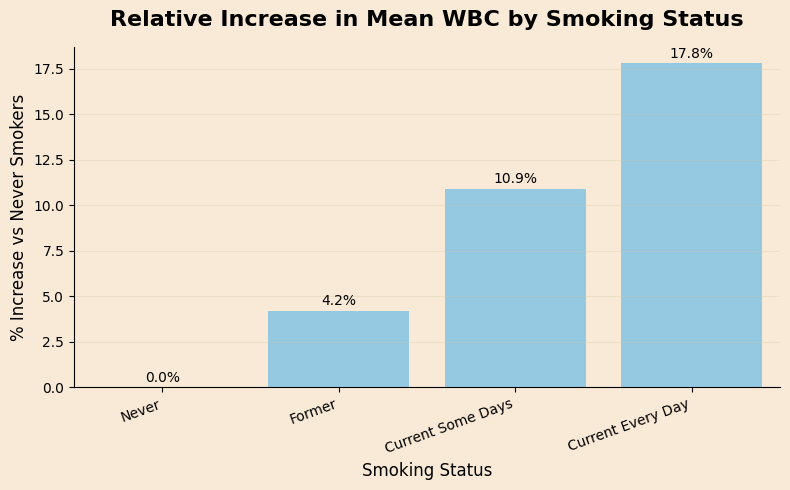

In [74]:
# Visualize relative increase in mean WBC count by smoking status compared to never smokers
wbc_increase = (
    (wbc_mean - wbc_mean["Never"])
    / wbc_mean["Never"]
    * 100
).round(1)

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=wbc_increase.index,
    y=wbc_increase.values,
    color="#88CCEE"
)

for i, value in enumerate(wbc_increase.values):
    plt.text(
        i,
        value + 0.3,
        f"{value:.1f}%",
        ha="center",
        fontsize=10
    )

style_chart(
    title="Relative Increase in Mean WBC by Smoking Status",
    xlabel="Smoking Status",
    ylabel="% Increase vs Never Smokers",
    rotation=20
)

plt.show()

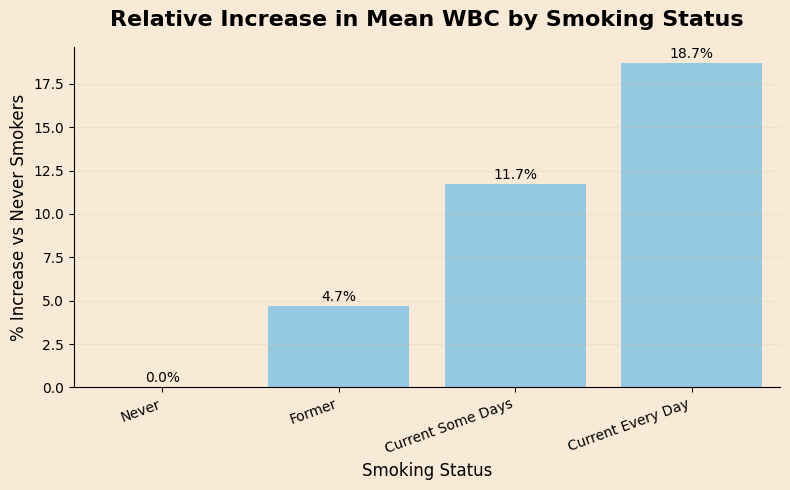

In [75]:
wbc_increase = (
    (wbc_median - wbc_median["Never"])
    / wbc_median["Never"]
    * 100
).round(1)

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=wbc_increase.index,
    y=wbc_increase.values,
    color="#88CCEE"
)

for i, value in enumerate(wbc_increase.values):
    plt.text(
        i,
        value + 0.3,
        f"{value:.1f}%",
        ha="center",
        fontsize=10
    )

style_chart(
    title="Relative Increase in Mean WBC by Smoking Status",
    xlabel="Smoking Status",
    ylabel="% Increase vs Never Smokers",
    rotation=20
)

plt.show()

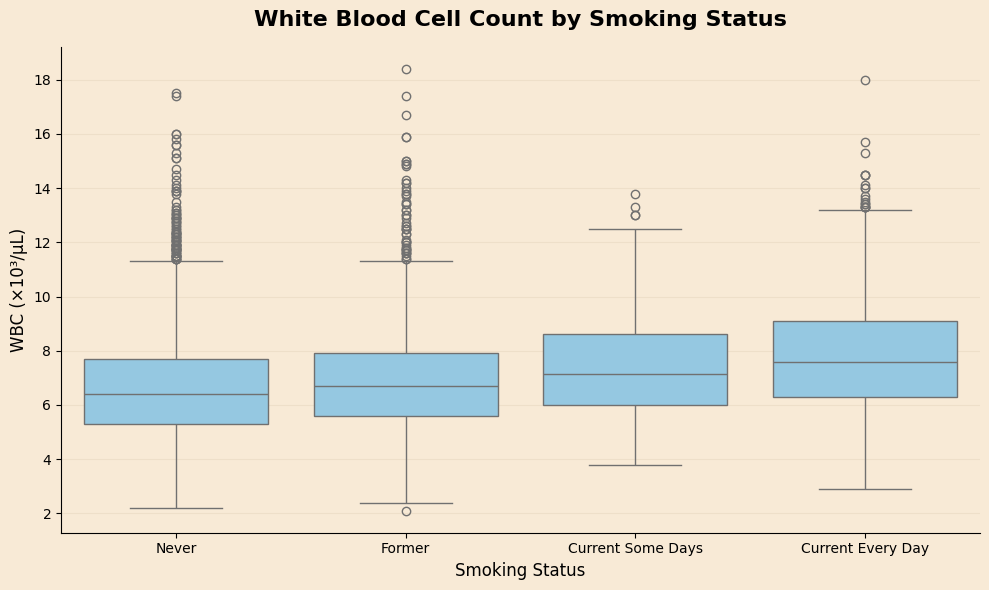

In [76]:
# Visualize distribution of WBC counts by smoking status using boxplot

smoking_order = [
    "Never",
    "Former",
    "Current Some Days",
    "Current Every Day"
]

plt.figure(figsize=(10,6))

sns.boxplot(
    data=smoking_df,
    x="smoking_status",
    y="wbc_abs.",
    order=smoking_order,
    color="#88CCEE"
)

style_chart(
    title="White Blood Cell Count by Smoking Status",
    xlabel="Smoking Status",
    ylabel="WBC (×10³/µL)"
)

plt.show()

## Neutrophils by Smoking


In [77]:
# Calculate median neutrophil count by smoking status
neut_median = smoking_df.groupby(
    "smoking_status",
    observed=True
)["neutrophils_abs."].median().sort_values()

neut_median

smoking_status
Never                3.7
Former               4.0
Current Some Days    4.1
Current Every Day    4.5
Name: neutrophils_abs., dtype: float64

In [80]:
neut_mean = smoking_df.groupby(
    "smoking_status",
    observed=True
)["neutrophils_abs."].mean().sort_values()
neut_mean

smoking_status
Never                3.944281
Former               4.209974
Current Some Days    4.422619
Current Every Day    4.759091
Name: neutrophils_abs., dtype: float64

In [78]:
# Calculate median neutrophil count by smoking status
summary = pd.DataFrame({
    "Median Neutrophils": neut_median,

})

summary["% Increase vs Never Smokers"] = (
    (summary["Median Neutrophils"] - summary.loc["Never", "Median Neutrophils"])
    / summary.loc["Never", "Median Neutrophils"]
    * 100
).round(1)

summary

,Median Neutrophils,% Increase vs Never Smokers
smoking_status,,
Never,3.7,0.0
Former,4.0,8.1
Current Some Days,4.1,10.8
Current Every Day,4.5,21.6


In [82]:
# calculate mean neutrophil count by smoking status
summary = pd.DataFrame({
    "Mean Neutrophils": neut_mean,

})

summary["% Increase vs Never Smokers"] = (
    (summary["Mean Neutrophils"] - summary.loc["Never", "Mean Neutrophils"])
    / summary.loc["Never", "Mean Neutrophils"]
    * 100
).round(1)

summary

,Mean Neutrophils,% Increase vs Never Smokers
smoking_status,,
Never,3.944281,0.0
Former,4.209974,6.7
Current Some Days,4.422619,12.1
Current Every Day,4.759091,20.7


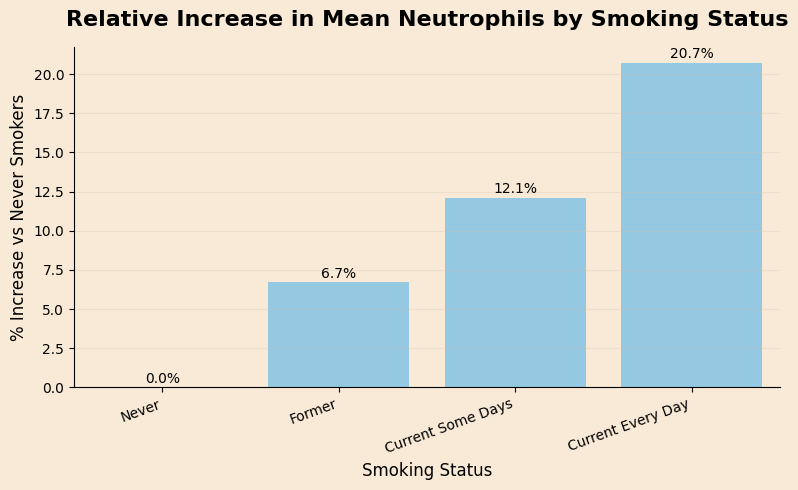

In [83]:
# Visualize relative increase in mean neutrophil count by smoking status compared to never smokers

neutrophil_increase = (
    (neut_mean - neut_mean["Never"])
    / neut_mean["Never"]
    * 100
).round(1)

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=neutrophil_increase.index,
    y=neutrophil_increase.values,
    color="#88CCEE"
)

for i, value in enumerate(neutrophil_increase.values):
    plt.text(
        i,
        value + 0.3,
        f"{value:.1f}%",
        ha="center",
        fontsize=10
    )

style_chart(
    title="Relative Increase in Mean Neutrophils by Smoking Status",
    xlabel="Smoking Status",
    ylabel="% Increase vs Never Smokers",
    rotation=20
)

plt.show()

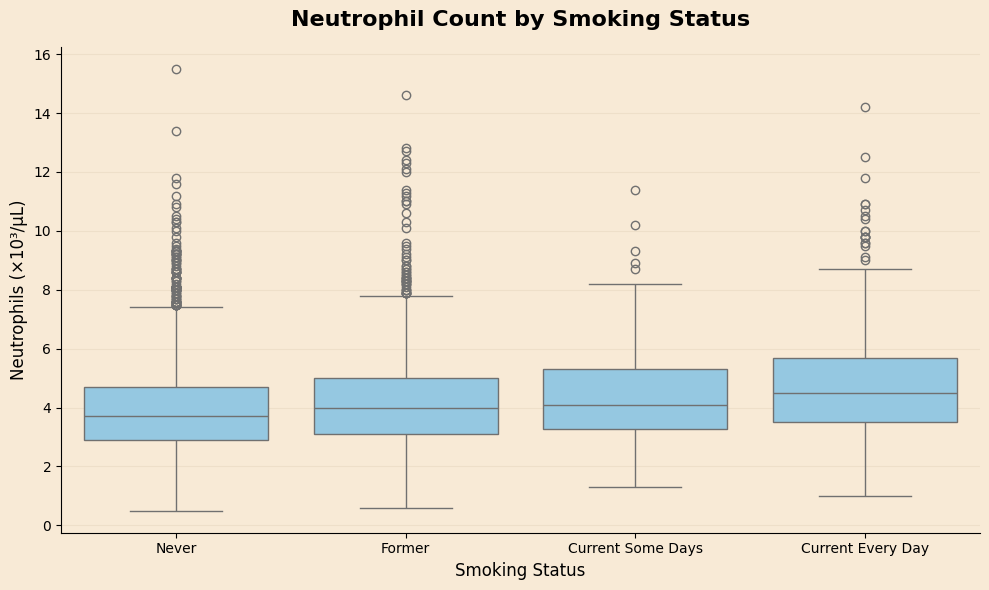

In [84]:
# Visualize distribution of neutrophil counts by smoking status using boxplot

smoking_order = [
    "Never",
    "Former",
    "Current Some Days",
    "Current Every Day"
]

plt.figure(figsize=(10,6))

sns.boxplot(
    data=smoking_df,
    x="smoking_status",
    y="neutrophils_abs.",
    order=smoking_order,
    color="#88CCEE"
)

style_chart(
    title="Neutrophil Count by Smoking Status",
    xlabel="Smoking Status",
    ylabel="Neutrophils (×10³/µL)"
)

plt.show()

In [85]:
# Create summary DataFrame combining median and mean WBC and neutrophil counts by smoking status, along with percentage increase compared to never smokers

summary = pd.DataFrame({
    "Median WBC": wbc_median,
    "Median Neutrophils": neut_median
})

summary["WBC % Increase"] = (
    (summary["Median WBC"] - summary.loc["Never", "Median WBC"])
    / summary.loc["Never", "Median WBC"]
    * 100
).round(1)

summary["Neutrophils % Increase"] = (
    (summary["Median Neutrophils"] - summary.loc["Never", "Median Neutrophils"])
    / summary.loc["Never", "Median Neutrophils"]
    * 100
).round(1)

summary

,Median WBC,Median Neutrophils,WBC % Increase,Neutrophils % Increase
smoking_status,,,,
Never,6.40,3.7,0.0,0.0
Former,6.70,4.0,4.7,8.1
Current Some Days,7.15,4.1,11.7,10.8
Current Every Day,7.60,4.5,18.7,21.6


In [86]:

# Calculate Spearman correlation between smoking score and WBC count
from scipy.stats import spearmanr

temp = smoking_df[
    ["smoking_score", "wbc_abs."]
].dropna()

corr, p = spearmanr(
    temp["smoking_score"],
    temp["wbc_abs."]
)

print(f"Spearman r = {corr:.3f}")
print(f"p-value = {p:.4e}")
print(f"N = {len(temp)}")

Spearman r = 0.165
p-value = 4.7056e-38
N = 5995


## Haematocrit and Smoking

In [87]:
# Calculate median hematocrit percentage by smoking status

smoking_df.groupby(
    "smoking_status",
    observed=True
)["hct_%"].median()

smoking_status
Current Every Day    42.7
Current Some Days    42.4
Former               41.3
Never                40.9
Name: hct_%, dtype: float64

In [88]:
# Calcuate mean hematocrit percentage by smoking status
smoking_df.groupby(
    "smoking_status",
    observed=True
)["hct_%"].mean().round(1)

smoking_status
Current Every Day    42.4
Current Some Days    41.9
Former               41.2
Never                40.8
Name: hct_%, dtype: float64

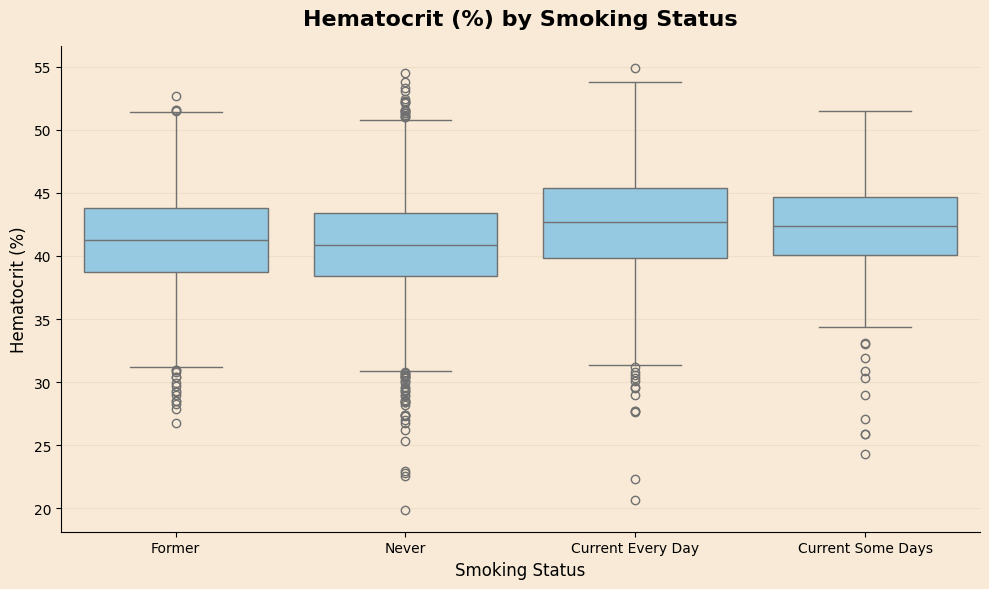

In [89]:
# Visualize distribution of hematocrit percentage by smoking status using boxplot

plt.figure(figsize=(10,6))

sns.boxplot(
    data=smoking_df,
    x="smoking_status",
    y="hct_%",
    color="#88CCEE"
)

style_chart(
    title="Hematocrit (%) by Smoking Status",
    xlabel="Smoking Status",
    ylabel="Hematocrit (%)"
)

plt.tight_layout()
plt.show()

In [90]:

# 
hct_median = smoking_df.groupby(
    "smoking_status",
    observed=True
)["hct_%"].median()

hct_summary = pd.DataFrame({
    "Median Hematocrit (%)": hct_median
})

hct_summary["% Increase vs Non-Smoker"] = (
    (hct_summary["Median Hematocrit (%)"]
     - hct_summary.loc["Never", "Median Hematocrit (%)"])
    / hct_summary.loc["Never", "Median Hematocrit (%)"]
    * 100
).round(1)

hct_summary

,Median Hematocrit (%),% Increase vs Non-Smoker
smoking_status,,
Current Every Day,42.7,4.4
Current Some Days,42.4,3.7
Former,41.3,1.0
Never,40.9,0.0


## All Haematology and Smoking

In [91]:
# Create list of hematology-related columns for later use in correlation analysis and visualization
haem_cols = [
    "wbc_abs.",
    "neutrophils_abs.",
    "lymphocytes_abs.",
    "monocytes_abs.",
    "rbc",
    "haemoglobin_mmol/l",
    "hct_%",
    "mcv_fl",
    "mchpg",
    "mchcg/dl",
    "rdw%",
    "plt1000/μl",
    "mpvfl",
    "nlr"
]

In [92]:
# Calculate median and mean values for each hematology parameter by smoking status, along with percentage change compared to never smokers, and compile results into a summary DataFrame

results = []

for col in haem_cols:

    medians = smoking_df.groupby(
        "smoking_status",
        observed=True
    )[col].median()

    means = smoking_df.groupby(
        "smoking_status",
        observed=True
    )[col].mean()

    results.append({
        "Parameter": col,

        "Median Never": medians["Never"],
        "Median Former": medians["Former"],
        "Median Current Some Days": medians["Current Some Days"],
        "Median Current Every Day": medians["Current Every Day"],

        "Mean Never": means["Never"],
        "Mean Former": means["Former"],
        "Mean Current Some Days": means["Current Some Days"],
        "Mean Current Every Day": means["Current Every Day"],

        "% Change Median Current Every Day vs Never": (
            (medians["Current Every Day"] - medians["Never"])
            / medians["Never"] * 100
        ),

        "% Change Mean Current Every Day vs Never": (
            (means["Current Every Day"] - means["Never"])
            / means["Never"] * 100
        )
    })

smoking_haem_summary = pd.DataFrame(results)

smoking_haem_summary = (
    smoking_haem_summary
    .round(2)
    .sort_values("% Change Median Current Every Day vs Never", ascending=False)
)

smoking_haem_summary

,Parameter,Median Never,Median Former,Median Current Some Days,Median Current Every Day,Mean Never,Mean Former,Mean Current Some Days,Mean Current Every Day,% Change Median Current Every Day vs Never,% Change Mean Current Every Day vs Never
1,neutrophils_abs.,3.70,4.00,4.10,4.50,3.94,4.21,4.42,4.76,21.62,20.66
3,monocytes_abs.,0.50,0.50,0.50,0.60,0.52,0.56,0.58,0.60,20.00,13.84
0,wbc_abs.,6.40,6.70,7.15,7.60,6.68,6.96,7.42,7.87,18.75,17.81
2,lymphocytes_abs.,1.90,1.90,2.10,2.20,2.00,1.94,2.15,2.27,15.79,13.61
13,nlr,1.94,2.14,2.00,2.07,2.15,2.42,2.45,2.31,6.67,7.49
5,haemoglobin_mmol/l,8.57,8.69,8.85,9.00,8.55,8.63,8.76,8.91,5.07,4.21
6,hct_%,40.90,41.30,42.40,42.70,40.85,41.18,41.89,42.41,4.40,3.82
8,mchpg,29.90,30.30,30.30,30.80,29.69,30.12,29.88,30.54,3.01,2.85
10,rdw%,13.50,13.70,13.70,13.80,13.77,13.94,14.22,14.06,2.22,2.09
7,mcv_fl,88.60,89.50,89.85,90.40,88.07,89.25,88.69,90.24,2.03,2.46


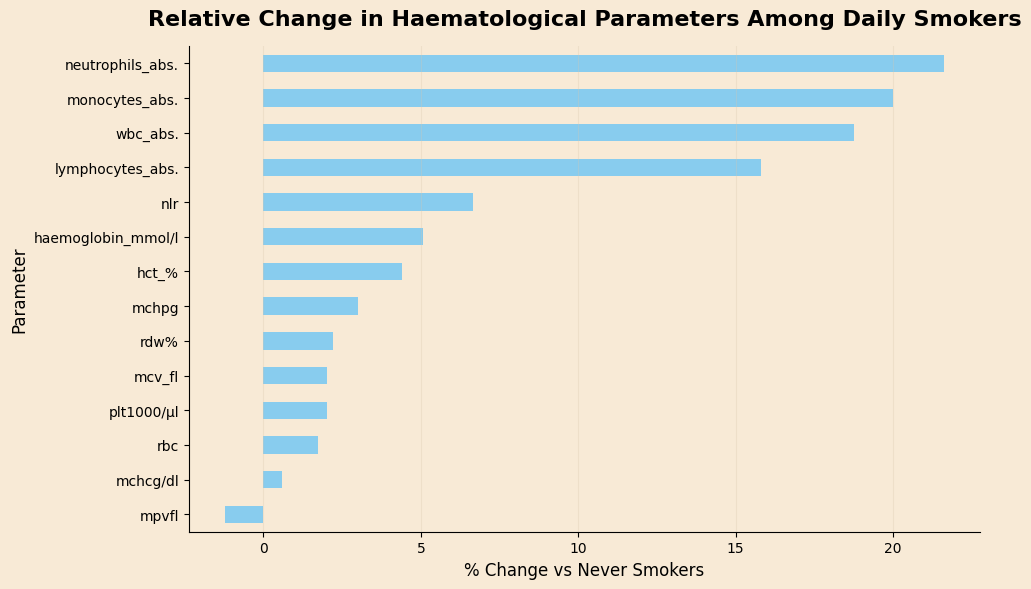

In [93]:
# Visualize relative change in median hematological parameters among daily smokers compared to never smokers

smoking_effects = (
    smoking_haem_summary
    .set_index("Parameter")["% Change Median Current Every Day vs Never"]
    .sort_values()
)

ax = smoking_effects.plot(
    kind="barh",
    figsize=(10,6),
    color="#88CCEE"
)

style_chart(
    title="Relative Change in Haematological Parameters Among Daily Smokers",
    xlabel="% Change vs Never Smokers",
    ylabel="Parameter",
    grid_axis="x"
)

plt.tight_layout()
plt.show()

In [94]:
smoking_score = {
    "Never": 0,
    "Former": 1,
    "Current Some Days": 2,
    "Current Every Day": 3
}

smoking_df["smoking_score"] = (
    smoking_df["smoking_status"]
    .map(smoking_score)
)

In [95]:
from scipy.stats import spearmanr

temp = smoking_df[["smoking_score", "wbc_abs."]].dropna()

print(temp.shape)

corr, p = spearmanr(
    temp["smoking_score"],
    temp["wbc_abs."]
)

print('r=', corr)
print('p-value=', p)

(5995, 2)
r= 0.16544886394945493
p-value= 4.705589395777801e-38


In [96]:
from scipy.stats import spearmanr

corr_results = []

for col in haem_cols:
    temp = smoking_df[["smoking_score", col]].dropna()

    corr, p = spearmanr(
        temp["smoking_score"],
        temp[col]
    )

    corr_results.append({
        "Parameter": col,
        "Spearman r": corr,
        "p-value": p,
        "n": len(temp)
    })

smoking_corr_table = pd.DataFrame(corr_results)

smoking_corr_table

,Parameter,Spearman r,p-value,n
0,wbc_abs.,0.165449,4.705589e-38,5995
1,neutrophils_abs.,0.151479,4.695335e-32,5985
2,lymphocytes_abs.,0.059862,3.582243e-06,5985
3,monocytes_abs.,0.145773,8.741942e-30,5985
4,rbc,0.031147,1.587735e-02,5995
5,haemoglobin_mmol/l,0.118733,2.863557e-20,5995
6,hct_%,0.115930,2.162784e-19,5995
7,mcv_fl,0.144026,3.737787e-29,5995
8,mchpg,0.139991,1.278485e-27,5995
9,mchcg/dl,0.042706,9.414245e-04,5995


In [97]:
parameter_labels = {
    "wbc_abs.": "WBC",
    "neutrophils_abs.": "Neutrophils",
    "monocytes_abs.": "Monocytes",
    "lymphocytes_abs.": "Lymphocytes",
    "hct_%": "Hematocrit",
    "haemoglobin_mmol/l": "Hemoglobin"
}

smoking_corr_table["Parameter"] = (
    smoking_corr_table["Parameter"]
    .map(parameter_labels)
)

smoking_corr_table = (
    smoking_corr_table
    .sort_values("Spearman r", ascending=False)
)

smoking_corr_table

,Parameter,Spearman r,p-value,n
0,WBC,0.165449,4.705589e-38,5995
1,Neutrophils,0.151479,4.695335e-32,5985
3,Monocytes,0.145773,8.741942e-30,5985
7,NaN,0.144026,3.737787e-29,5995
8,NaN,0.139991,1.278485e-27,5995
5,Hemoglobin,0.118733,2.863557e-20,5995
6,Hematocrit,0.115930,2.162784e-19,5995
10,NaN,0.106769,1.143779e-16,5995
13,NaN,0.079402,7.690835e-10,5985
2,Lymphocytes,0.059862,3.582243e-06,5985


In [98]:
combined_smoking_summary = (
    smoking_haem_summary[
        [
            "Parameter",
            "% Change Median Current Every Day vs Never"
        ]
    ]
    .merge(
        smoking_corr_table[
            [
                "Parameter",
                "Spearman r"
            ]
        ],
        on="Parameter",
        how="left"
    )
    .round(3)
    .sort_values(
        "Spearman r",
        ascending=False
    )
)

combined_smoking_summary

,Parameter,% Change Median Current Every Day vs Never,Spearman r
0,neutrophils_abs.,21.62,NaN
1,monocytes_abs.,20.00,NaN
2,wbc_abs.,18.75,NaN
3,lymphocytes_abs.,15.79,NaN
4,nlr,6.67,NaN
5,haemoglobin_mmol/l,5.07,NaN
6,hct_%,4.40,NaN
7,mchpg,3.01,NaN
8,rdw%,2.22,NaN
9,mcv_fl,2.03,NaN


## Alcohol & Liver Function


In [99]:
df.columns

Index(['id', 'gender', 'age', 'ethnicity', 'weight_kg', 'height_cm', 'bmi',
       'waist_circumference_cm', 'hip_circumference_cm', 'waist_hip_ratio',
       'wbc_abs.', 'lymphocytes_abs.', 'monocytes_abs.', 'nlr',
       'neutrophils_abs.', 'rbc', 'haemoglobin_mmol/l', 'hct_%', 'mcv_fl',
       'mchcg/dl', 'mchpg', 'rdw%', 'plt1000/μl', 'mpvfl', 'ferritin_ng/ml',
       'folate_nmol/l', 'alc_consum?', 'alc_<12m?', 'alcohol_frequency_12m',
       'smoked_100_cigs?', 'smoker_now?', 'high_bp?', 'bp_medication?',
       'mean_systolic_bp', 'mean_diastolic_bp', 'mean_pulse',
       'high_cholesterol?', 'cholesterol_medication?', 'diabetes?',
       'pre_diabetes?', 'insulin?', 'diabetes_medication?', 'alt_iu/l',
       'albumin_g/l', 'ast_iu/l', 'glucose_mmol/l', 'ggt_iu/l', 'iron_μmol/l',
       'total_bilirubin_μmol/l', 'cholesterol_mmol/l', 'total_protein_g/l',
       'uric_acid_μmol/l', 'crp_mg/l', 'hba1c_%', 'vitamin_d_nmol/l',
       'total_cholesterol_mmol/l', 'ldl_mmol/l', 'hdl_mm

In [100]:
df["alc_consum?"].value_counts(dropna=False)

alc_consum?
1.0    4918
NaN    2672
2.0     558
9.0       5
Name: count, dtype: int64

In [101]:
df["alcohol_frequency_12m"].value_counts(dropna=False)

alcohol_frequency_12m
NaN      4084
1.0      1345
2.0      1312
3.0       599
4.0       251
5.0       216
6.0       141
12.0       55
8.0        42
10.0       31
15.0       20
9.0        19
7.0        17
999.0      10
777.0       4
11.0        4
14.0        2
13.0        1
Name: count, dtype: int64

In [102]:
pd.crosstab(
    df["alc_consum?"],
    df["alcohol_frequency_12m"],
    dropna=False
)

alcohol_frequency_12m,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,777.0,999.0,NaN
alc_consum?,,,,,,,,,,,,,,,,,,
1.0,1344,1312,599,251,216,141,17,42,19,31,4,55,1,2,20,4,10,850
2.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,558
9.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4
NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2672


In [103]:
df.loc[
    (df["alc_consum?"] == 1)
    & (df["alcohol_frequency_12m"].isna())
].shape

(850, 67)

In [104]:
missing_alcohol_freq = df[
    (df["alc_consum?"] == 1)
    & (df["alcohol_frequency_12m"].isna())
]

len(missing_alcohol_freq)

850

In [105]:
df.groupby(
    (df["alc_consum?"] == 1)
    & (df["alcohol_frequency_12m"].isna())
)["age"].describe()

,count,mean,std,min,25%,50%,75%,max
False,7303.0,51.245379,18.682796,18.0,35.0,53.0,67.0,80.0
True,850.0,59.868235,15.375061,18.0,51.0,64.0,71.0,80.0


In [106]:
df.columns[df.columns.str.contains(
    "ast|alt|ggt|alp|bilir",
    case=False,
    regex=True
)]

Index(['mean_diastolic_bp', 'alt_iu/l', 'ast_iu/l', 'ggt_iu/l',
       'total_bilirubin_μmol/l'],
      dtype='str')

In [107]:
df["alcohol_frequency_group"].value_counts(dropna=False)


alcohol_frequency_group
NaN                   4180
Daily / Near daily    2657
Weekly                1066
Monthly                158
Few times/year          92
Name: count, dtype: int64

In [108]:
df["alcohol_frequency_12m"].value_counts(dropna=False).sort_index()

alcohol_frequency_12m
1.0      1345
2.0      1312
3.0       599
4.0       251
5.0       216
6.0       141
7.0        17
8.0        42
9.0        19
10.0       31
11.0        4
12.0       55
13.0        1
14.0        2
15.0       20
777.0       4
999.0      10
NaN      4084
Name: count, dtype: int64

In [109]:
df.columns

Index(['id', 'gender', 'age', 'ethnicity', 'weight_kg', 'height_cm', 'bmi',
       'waist_circumference_cm', 'hip_circumference_cm', 'waist_hip_ratio',
       'wbc_abs.', 'lymphocytes_abs.', 'monocytes_abs.', 'nlr',
       'neutrophils_abs.', 'rbc', 'haemoglobin_mmol/l', 'hct_%', 'mcv_fl',
       'mchcg/dl', 'mchpg', 'rdw%', 'plt1000/μl', 'mpvfl', 'ferritin_ng/ml',
       'folate_nmol/l', 'alc_consum?', 'alc_<12m?', 'alcohol_frequency_12m',
       'smoked_100_cigs?', 'smoker_now?', 'high_bp?', 'bp_medication?',
       'mean_systolic_bp', 'mean_diastolic_bp', 'mean_pulse',
       'high_cholesterol?', 'cholesterol_medication?', 'diabetes?',
       'pre_diabetes?', 'insulin?', 'diabetes_medication?', 'alt_iu/l',
       'albumin_g/l', 'ast_iu/l', 'glucose_mmol/l', 'ggt_iu/l', 'iron_μmol/l',
       'total_bilirubin_μmol/l', 'cholesterol_mmol/l', 'total_protein_g/l',
       'uric_acid_μmol/l', 'crp_mg/l', 'hba1c_%', 'vitamin_d_nmol/l',
       'total_cholesterol_mmol/l', 'ldl_mmol/l', 'hdl_mm

In [110]:
df["alc_<12m?"].value_counts(dropna=False)

alc_<12m?
NaN             3231
5.397605e-79     836
6.000000e+00     574
1.000000e+01     542
9.000000e+00     517
4.000000e+00     483
3.000000e+00     458
5.000000e+00     420
7.000000e+00     362
2.000000e+00     301
8.000000e+00     261
1.000000e+00     163
9.900000e+01       3
7.700000e+01       2
Name: count, dtype: int64

In [111]:
df["alc_<12m?"] = (
    df["alc_<12m?"]
    .replace(5.397605346934028e-79, 0)
)

In [112]:
sorted(df["alc_<12m?"].dropna().unique())

[np.float64(0.0),
 np.float64(1.0),
 np.float64(2.0),
 np.float64(3.0),
 np.float64(4.0),
 np.float64(5.0),
 np.float64(6.0),
 np.float64(7.0),
 np.float64(8.0),
 np.float64(9.0),
 np.float64(10.0),
 np.float64(77.0),
 np.float64(99.0)]

In [113]:
# Remove refused / don't know
df["alc_<12m?"] = df["alc_<12m?"].replace({
    77: pd.NA,
    99: pd.NA
})

# Create alcohol frequency categories
alcohol_map = {
    0: "Former / None Last Year",

    1: "Daily / Near Daily",
    2: "Daily / Near Daily",

    3: "Weekly",
    4: "Weekly",
    5: "Weekly",

    6: "Monthly",
    7: "Monthly",

    8: "Few Times / Year",
    9: "Few Times / Year",
    10: "Few Times / Year"
}

df["alcohol_frequency_group"] = (
    df["alc_<12m?"]
    .map(alcohol_map)
)

# Add never drinkers
df.loc[
    df["alc_consum?"] == 2,
    "alcohol_frequency_group"
] = "Never Drank"

In [114]:
df["alcohol_frequency_group"].value_counts(dropna=False)

alcohol_frequency_group
NaN                        2678
Weekly                     1361
Few Times / Year           1320
Monthly                     936
Former / None Last Year     836
Never Drank                 558
Daily / Near Daily          464
Name: count, dtype: int64

In [115]:
alcohol_df = df[
    df["alcohol_frequency_group"].notna()
].copy()

In [116]:
alcohol_dist = (
    alcohol_df["alcohol_frequency_group"]
    .value_counts(normalize=True)
    .mul(100)
)

alcohol_order = [
    "Never Drank",
    "Former / None Last Year",
    "Few Times / Year",
    "Monthly",
    "Weekly",
    "Daily / Near Daily"
]

alcohol_dist = alcohol_dist.reindex(alcohol_order)

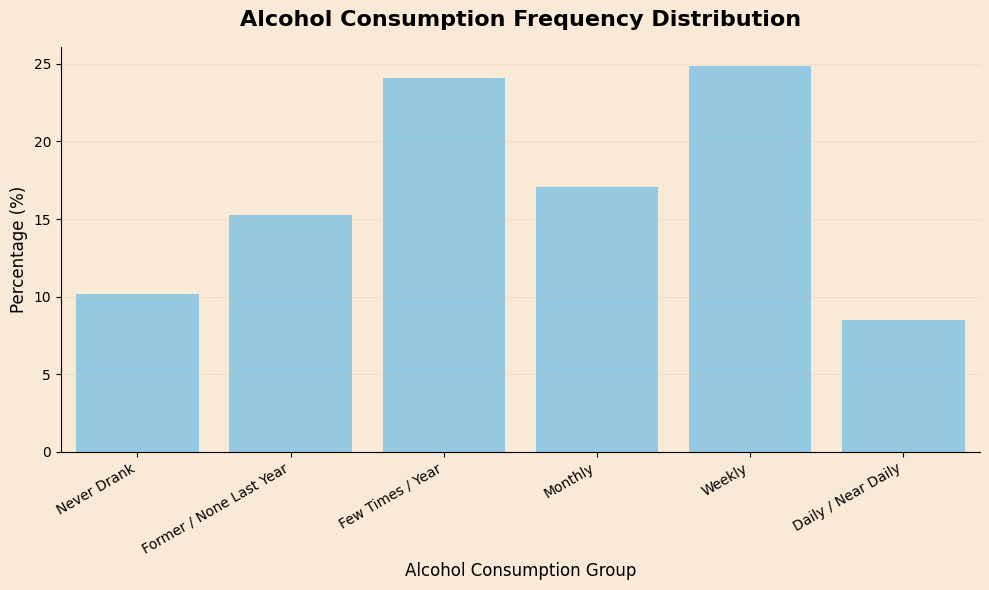

In [117]:
alcohol_dist = (
    alcohol_df["alcohol_frequency_group"]
    .value_counts(normalize=True)
    .mul(100)
    .reindex([
        "Never Drank",
        "Former / None Last Year",
        "Few Times / Year",
        "Monthly",
        "Weekly",
        "Daily / Near Daily"
    ])
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=alcohol_dist.index,
    y=alcohol_dist.values,
    color="#88CCEE"
)

style_chart(
    title="Alcohol Consumption Frequency Distribution",
    xlabel="Alcohol Consumption Group",
    ylabel="Percentage (%)",
    rotation=30
)

plt.show()

In [118]:
# Explore distribution of alcohol consumption frequency groups
alcohol_df["alcohol_frequency_group"].value_counts()

alcohol_frequency_group
Weekly                     1361
Few Times / Year           1320
Monthly                     936
Former / None Last Year     836
Never Drank                 558
Daily / Near Daily          464
Name: count, dtype: int64

In [119]:
# Explore relationship between alcohol consumption frequency and liver enzyme levels (median GGT, ALT, AST by alcohol frequency group)

alcohol_df.groupby(
    "alcohol_frequency_group",
    observed=True
)[
    ["ggt_iu/l", "alt_iu/l", "ast_iu/l"]
].median()

,ggt_iu/l,alt_iu/l,ast_iu/l
alcohol_frequency_group,,,
Daily / Near Daily,28.0,20.0,23.0
Few Times / Year,19.0,17.0,19.0
Former / None Last Year,19.0,18.0,20.0
Monthly,19.0,18.0,19.0
Never Drank,19.0,16.0,19.0
Weekly,20.0,18.0,21.0


In [120]:
# Explore relationship between alcohol consumption frequency and liver enzyme levels (mean GGT, ALT, AST by alcohol frequency group)
alcohol_df.groupby(
    "alcohol_frequency_group",
    observed=True
)[
    ["ggt_iu/l", "alt_iu/l", "ast_iu/l"]
].mean()

,ggt_iu/l,alt_iu/l,ast_iu/l
alcohol_frequency_group,,,
Daily / Near Daily,56.390588,27.197647,28.124706
Few Times / Year,25.838435,20.758503,21.097956
Former / None Last Year,28.416107,21.342282,22.538978
Monthly,26.036817,21.928571,22.198565
Never Drank,27.297131,20.241803,21.702259
Weekly,28.544365,21.844676,22.735577


### GGT

In [121]:
alcohol_df.groupby(
    "alcohol_frequency_group",
    observed=True
)["ggt_iu/l"].describe()

,count,mean,std,min,25%,50%,75%,max
alcohol_frequency_group,,,,,,,,
Daily / Near Daily,425.0,56.390588,122.024077,7.0,17.0,28.0,47.0,1541.0
Few Times / Year,1176.0,25.838435,28.978045,4.0,13.0,19.0,28.0,407.0
Former / None Last Year,745.0,28.416107,33.695286,4.0,13.0,19.0,31.0,402.0
Monthly,842.0,26.036817,32.030081,5.0,13.0,19.0,29.0,434.0
Never Drank,488.0,27.297131,32.922718,4.0,13.0,19.0,29.0,480.0
Weekly,1251.0,28.544365,31.585291,2.0,14.0,20.0,30.0,333.0


In [122]:
alcohol_df["log_ggt"] = np.log1p(alcohol_df["ggt_iu/l"])

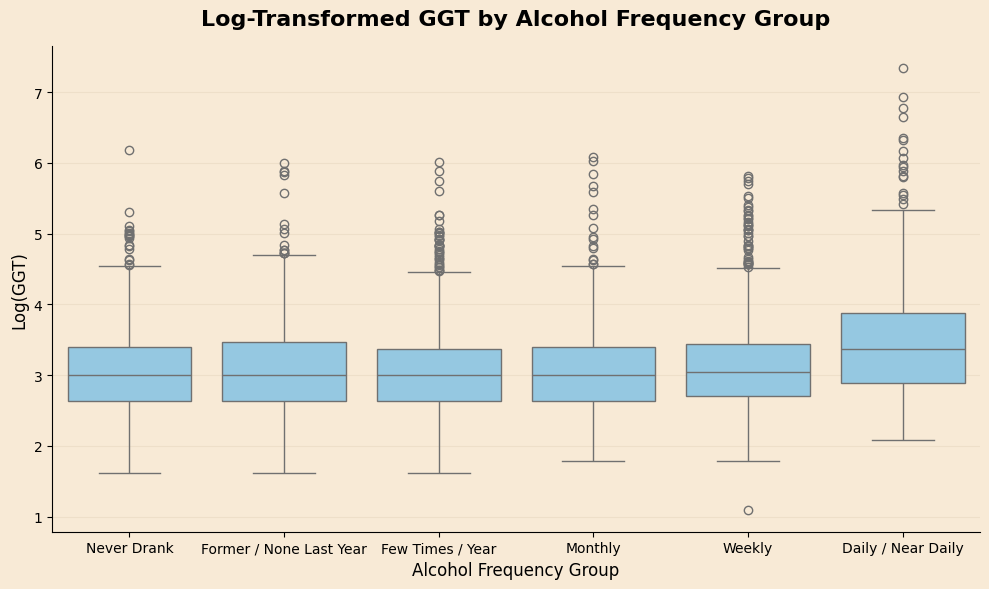

In [123]:
order = [
    "Never Drank",
    "Former / None Last Year",
    "Few Times / Year",
    "Monthly",
    "Weekly",
    "Daily / Near Daily"
]

plt.figure(figsize=(10,6))

sns.boxplot(
    data=alcohol_df,
    x="alcohol_frequency_group",
    y="log_ggt",
    order=order,
    color="#88CCEE"
)

style_chart(
    title="Log-Transformed GGT by Alcohol Frequency Group",
    xlabel="Alcohol Frequency Group",
    ylabel="Log(GGT)"
)

plt.tight_layout()
plt.show()

In [124]:
alcohol_score_map = {
    "Never Drank": 0,
    "Former / None Last Year": 1,
    "Few Times / Year": 2,
    "Monthly": 3,
    "Weekly": 4,
    "Daily / Near Daily": 5
}

alcohol_df["alcohol_score"] = (
    alcohol_df["alcohol_frequency_group"]
    .map(alcohol_score_map)
)

temp = alcohol_df[
    ["alcohol_score", "log_ggt"]
].dropna()

corr, p = spearmanr(
    temp["alcohol_score"],
    temp["log_ggt"]
)

print(f"Correlation: {corr}")
print(f"P-value: {p}")

Correlation: 0.09260211417011316
P-value: 7.399416193313001e-11


In [125]:
df.columns

Index(['id', 'gender', 'age', 'ethnicity', 'weight_kg', 'height_cm', 'bmi',
       'waist_circumference_cm', 'hip_circumference_cm', 'waist_hip_ratio',
       'wbc_abs.', 'lymphocytes_abs.', 'monocytes_abs.', 'nlr',
       'neutrophils_abs.', 'rbc', 'haemoglobin_mmol/l', 'hct_%', 'mcv_fl',
       'mchcg/dl', 'mchpg', 'rdw%', 'plt1000/μl', 'mpvfl', 'ferritin_ng/ml',
       'folate_nmol/l', 'alc_consum?', 'alc_<12m?', 'alcohol_frequency_12m',
       'smoked_100_cigs?', 'smoker_now?', 'high_bp?', 'bp_medication?',
       'mean_systolic_bp', 'mean_diastolic_bp', 'mean_pulse',
       'high_cholesterol?', 'cholesterol_medication?', 'diabetes?',
       'pre_diabetes?', 'insulin?', 'diabetes_medication?', 'alt_iu/l',
       'albumin_g/l', 'ast_iu/l', 'glucose_mmol/l', 'ggt_iu/l', 'iron_μmol/l',
       'total_bilirubin_μmol/l', 'cholesterol_mmol/l', 'total_protein_g/l',
       'uric_acid_μmol/l', 'crp_mg/l', 'hba1c_%', 'vitamin_d_nmol/l',
       'total_cholesterol_mmol/l', 'ldl_mmol/l', 'hdl_mm

In [127]:
df = df.rename(columns={
    "alcohol_frequency_12m": "avg_drink_day_12m"
})

In [128]:
avg_drink_day_12m_clean = (
    df["avg_drink_day_12m"]
    .replace({
        777: pd.NA,
        999: pd.NA
    })
)

avg_drink_day_12m_clean.value_counts().sort_index()

avg_drink_day_12m
1.0     1345
2.0     1312
3.0      599
4.0      251
5.0      216
6.0      141
7.0       17
8.0       42
9.0       19
10.0      31
11.0       4
12.0      55
13.0       1
14.0       2
15.0      20
Name: count, dtype: int64

In [129]:
alcohol_qty_df = df.copy()

alcohol_qty_df["avg_drink_day_12m"] = pd.to_numeric(
    alcohol_qty_df["avg_drink_day_12m"],
    errors="coerce"
)

alcohol_qty_df["avg_drink_day_12m"] = alcohol_qty_df["avg_drink_day_12m"].replace({
    777: np.nan,
    999: np.nan
})

In [130]:
alcohol_qty_df["alcohol_quantity_group"] = pd.cut(
    alcohol_qty_df["avg_drink_day_12m"],
    bins=[0, 1, 2, 4, 15],
    labels=[
        "1 Drink",
        "2 Drinks",
        "3-4 Drinks",
        "5+ Drinks"
    ],
    include_lowest=True
)

In [131]:
alcohol_qty_df["alcohol_quantity_group"].value_counts(dropna=False)

alcohol_quantity_group
NaN           4098
1 Drink       1345
2 Drinks      1312
3-4 Drinks     850
5+ Drinks      548
Name: count, dtype: int64

In [132]:
alcohol_qty_df["log_ggt"] = np.log1p(alcohol_qty_df["ggt_iu/l"])

order = ["1 Drink", "2 Drinks", "3-4 Drinks", "5+ Drinks"]

alcohol_qty_df.groupby(
    "alcohol_quantity_group",
    observed=True
)["ggt_iu/l"].median().reindex(order)

alcohol_quantity_group
1 Drink       18.0
2 Drinks      20.0
3-4 Drinks    21.0
5+ Drinks     25.0
Name: ggt_iu/l, dtype: float64

In [133]:
ggt_median = (
    alcohol_qty_df.groupby(
        "alcohol_quantity_group",
        observed=True
    )["ggt_iu/l"]
    .median()
    .reindex([
        "1 Drink",
        "2 Drinks",
        "3-4 Drinks",
        "5+ Drinks"
    ])
)

(
    (ggt_median - ggt_median["1 Drink"])
    / ggt_median["1 Drink"]
    * 100
).round(1)

alcohol_quantity_group
1 Drink        0.0
2 Drinks      11.1
3-4 Drinks    16.7
5+ Drinks     38.9
Name: ggt_iu/l, dtype: float64

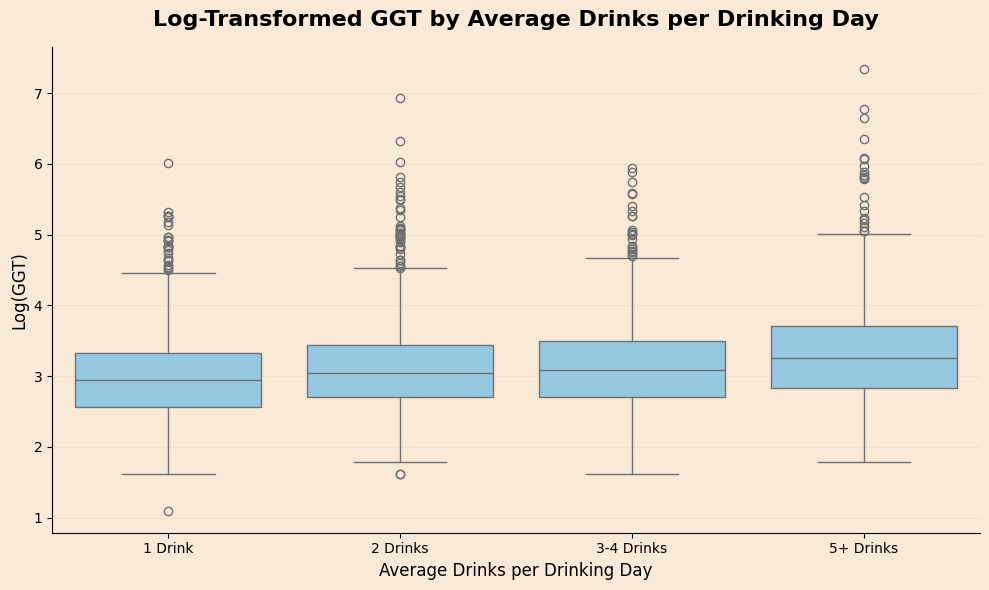

In [134]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=alcohol_qty_df,
    x="alcohol_quantity_group",
    y="log_ggt",
    order=order,
    color="#88CCEE"
)

style_chart(
    title="Log-Transformed GGT by Average Drinks per Drinking Day",
    xlabel="Average Drinks per Drinking Day",
    ylabel="Log(GGT)"
)

plt.show()

In [135]:

temp = alcohol_qty_df[
    ["avg_drink_day_12m", "log_ggt"]
].dropna()

corr, p = spearmanr(
    temp["avg_drink_day_12m"],
    temp["log_ggt"]
)

print(f"Spearman r = {corr:.3f}")
print(f"P-value = {p:.4e}")

Spearman r = 0.146
P-value = 5.8033e-19


In [136]:
markers = [
    "ggt_iu/l",
    "alt_iu/l",
    "ast_iu/l",
    "total_bilirubin_μmol/l"
]

pct_results = []

for col in markers:

    medians = alcohol_qty_df.groupby(
        "alcohol_quantity_group",
        observed=True
    )[col].median()

    pct_change = (
        (medians["5+ Drinks"] - medians["1 Drink"])
        / medians["1 Drink"] * 100
    )

    pct_results.append({
        "Marker": col,
        "% Increase (5+ Drinks vs 1 Drink)": round(pct_change, 1)
    })

pct_table = pd.DataFrame(pct_results)

pct_table

,Marker,% Increase (5+ Drinks vs 1 Drink)
0,ggt_iu/l,38.9
1,alt_iu/l,17.6
2,ast_iu/l,5.0
3,total_bilirubin_μmol/l,0.0


In [137]:


corr_results = []

for col in markers:

    temp = alcohol_qty_df[
        ["avg_drink_day_12m", col]
    ].dropna()

    corr, p = spearmanr(
        temp["avg_drink_day_12m"],
        temp[col]
    )

    corr_results.append({
        "Marker": col,
        "Spearman r": round(corr, 3),
        "p-value": p
    })

alcohol_corr_table = pd.DataFrame(corr_results)

alcohol_corr_table

,Marker,Spearman r,p-value
0,ggt_iu/l,0.146,5.803292e-19
1,alt_iu/l,0.110,2.013767e-11
2,ast_iu/l,0.051,1.860682e-03
3,total_bilirubin_μmol/l,-0.015,3.527473e-01


In [138]:
alcohol_summary = pct_table.merge(
    alcohol_corr_table,
    on="Marker"
)

alcohol_summary.sort_values(
    "Spearman r",
    ascending=False
)

,Marker,% Increase (5+ Drinks vs 1 Drink),Spearman r,p-value
0,ggt_iu/l,38.9,0.146,5.803292e-19
1,alt_iu/l,17.6,0.110,2.013767e-11
2,ast_iu/l,5.0,0.051,1.860682e-03
3,total_bilirubin_μmol/l,0.0,-0.015,3.527473e-01


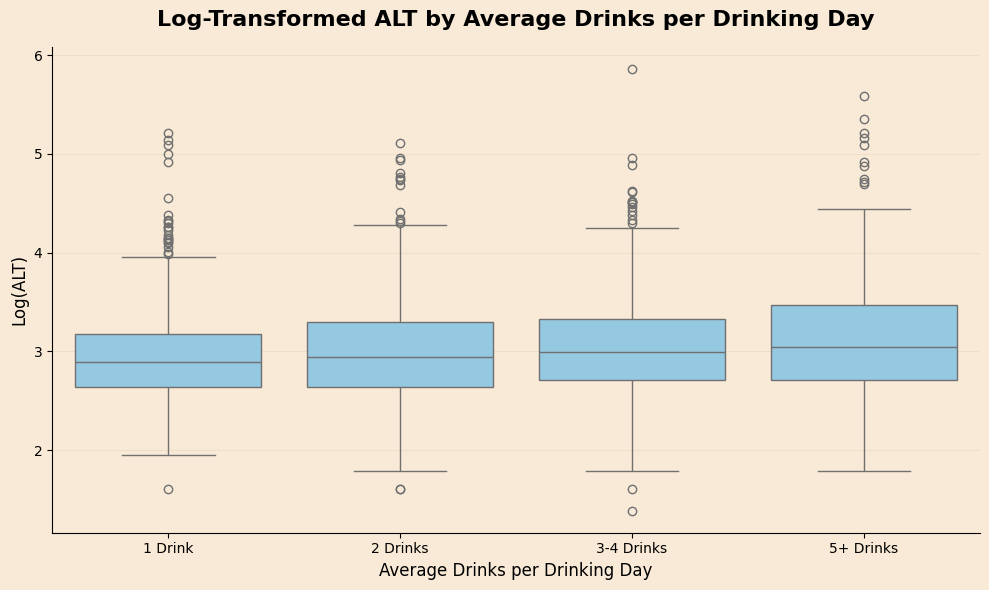

In [139]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=alcohol_qty_df,
    x="alcohol_quantity_group",
    y=np.log1p(alcohol_qty_df["alt_iu/l"]),
    order=["1 Drink", "2 Drinks", "3-4 Drinks", "5+ Drinks"],
    color="#88CCEE"
)

style_chart(
    title="Log-Transformed ALT by Average Drinks per Drinking Day",
    xlabel="Average Drinks per Drinking Day",
    ylabel="Log(ALT)"
)

plt.show()

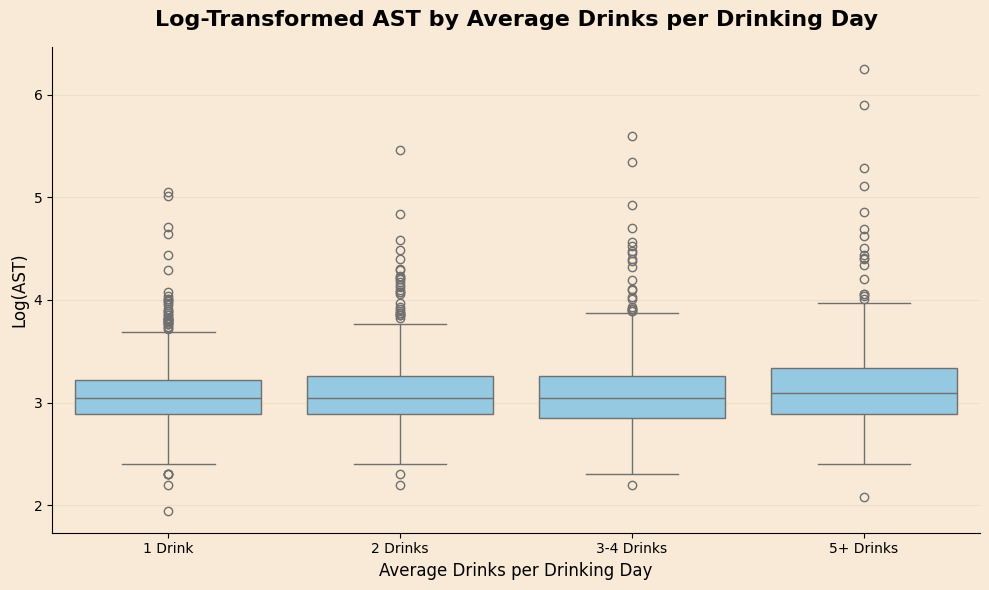

In [140]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=alcohol_qty_df,
    x="alcohol_quantity_group",
    y=np.log1p(alcohol_qty_df["ast_iu/l"]),
    order=["1 Drink", "2 Drinks", "3-4 Drinks", "5+ Drinks"],
    color="#88CCEE"
)

style_chart(
    title="Log-Transformed AST by Average Drinks per Drinking Day",
    xlabel="Average Drinks per Drinking Day",
    ylabel="Log(AST)"
)

plt.show()

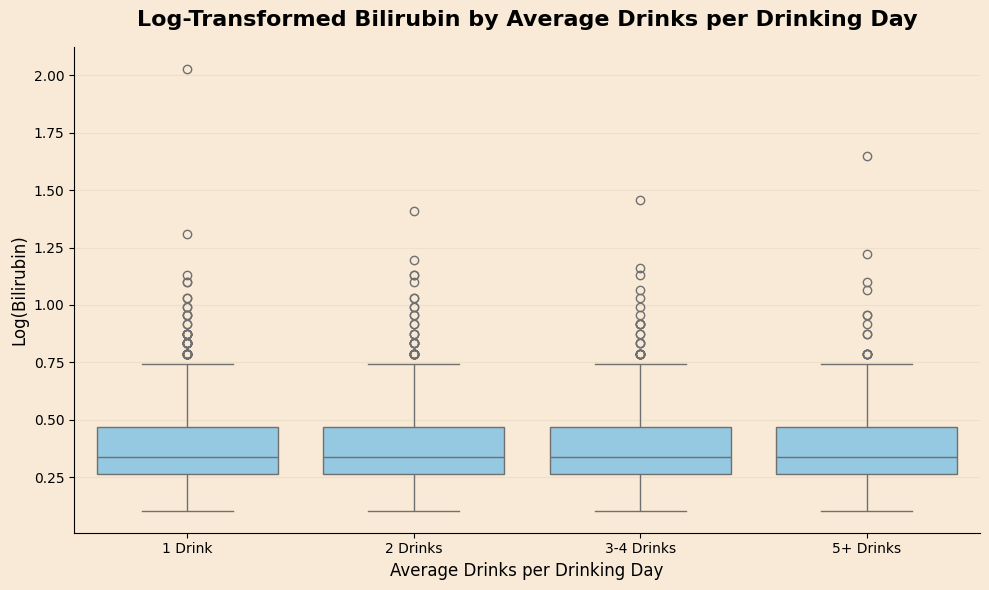

In [141]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=alcohol_qty_df,
    x="alcohol_quantity_group",
    y=np.log1p(alcohol_qty_df["total_bilirubin_μmol/l"]),
    order=["1 Drink", "2 Drinks", "3-4 Drinks", "5+ Drinks"],
    color="#88CCEE"
)

style_chart(
    title="Log-Transformed Bilirubin by Average Drinks per Drinking Day",
    xlabel="Average Drinks per Drinking Day",
    ylabel="Log(Bilirubin)"
)

plt.show()

In [142]:
alcohol_compare = pd.DataFrame({
    "Analysis": [
        "Alcohol Frequency",
        "Alcohol Quantity"
    ],
    "Spearman r (GGT)": [
        0.093,
        0.146
    ]
})

alcohol_compare

,Analysis,Spearman r (GGT)
0,Alcohol Frequency,0.093
1,Alcohol Quantity,0.146


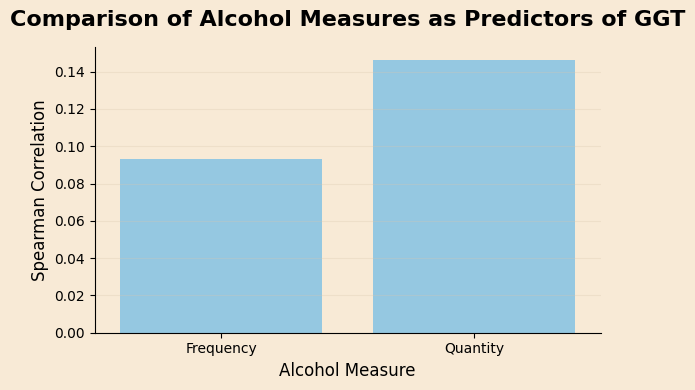

In [143]:
compare_df = pd.DataFrame({
    "Measure": [
        "Frequency",
        "Quantity"
    ],
    "Spearman r": [
        0.093,
        0.146
    ]
})

plt.figure(figsize=(6,4))

sns.barplot(
    data=compare_df,
    x="Measure",
    y="Spearman r",
    color="#88CCEE"
)

style_chart(
    title="Comparison of Alcohol Measures as Predictors of GGT",
    xlabel="Alcohol Measure",
    ylabel="Spearman Correlation"
)

plt.show()

In [144]:
alcohol_qty_df.groupby(
    "alcohol_quantity_group",
    observed=True
)["mcv_fl"].median()

alcohol_quantity_group
1 Drink       89.30
2 Drinks      89.10
3-4 Drinks    89.40
5+ Drinks     88.85
Name: mcv_fl, dtype: float64

In [145]:
mcv_median = (
    alcohol_qty_df.groupby(
        "alcohol_quantity_group",
        observed=True
    )["mcv_fl"]
    .median()
)

(
    (mcv_median - mcv_median["1 Drink"])
    / mcv_median["1 Drink"]
    * 100
).round(1)

alcohol_quantity_group
1 Drink       0.0
2 Drinks     -0.2
3-4 Drinks    0.1
5+ Drinks    -0.5
Name: mcv_fl, dtype: float64

In [146]:
import statsmodels.api as sm

model_df = df[
    [
        "log_crp",
        "bmi",
        "age",
        "gender",
        "smoking_score"
    ]
].dropna()

X = model_df[
    [
        "bmi",
        "age",
        "gender",
        "smoking_score"
    ]
]

X = sm.add_constant(X)

y = model_df["log_crp"]

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                log_crp   R-squared:                       0.256
Model:                            OLS   Adj. R-squared:                  0.255
Method:                 Least Squares   F-statistic:                     492.3
Date:                Tue, 02 Jun 2026   Prob (F-statistic):               0.00
Time:                        15:29:00   Log-Likelihood:                -5705.0
No. Observations:                5732   AIC:                         1.142e+04
Df Residuals:                    5727   BIC:                         1.145e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -0.6219      0.051    -12.313